# AI Powered Resume Screening - Recommender Systems + XAI

## MSc Artificial Intelligence | Dublin Business School
**Student Name:** Deepak Kumar | **Student ID:** 20097302 &nbsp;|&nbsp; **Module:** Recommender System (CA-02) | **Lecturer:** Dr. Nitya Govindaraju


---

## Overview

I have implemented a complete AI resume screening pipeline with:

| Component | Method |
|-----------|--------|
| **Recommender System 1** | Content-Based Filtering (TF-IDF + Cosine Similarity) |
| **Recommender System 2** | Collaborative Filtering (SVD Matrix Factorisation) |
| **Traditional ML Models** | Logistic Regression & Decision Tree |
| **Black-Box Models** | Random Forest & XGBoost |
| **XAI Method 1** | SHAP (SHapley Additive exPlanations) |
| **XAI Method 2** | LIME (Local Interpretable Model-agnostic Explanations) |
| **Deployment** | Flask Application and ngrok cloud |

**Dataset:** AI_Resume_Screening.csv - 1,000 candidates, 11 features, 4 Job Roles, binary Recruiter Decision


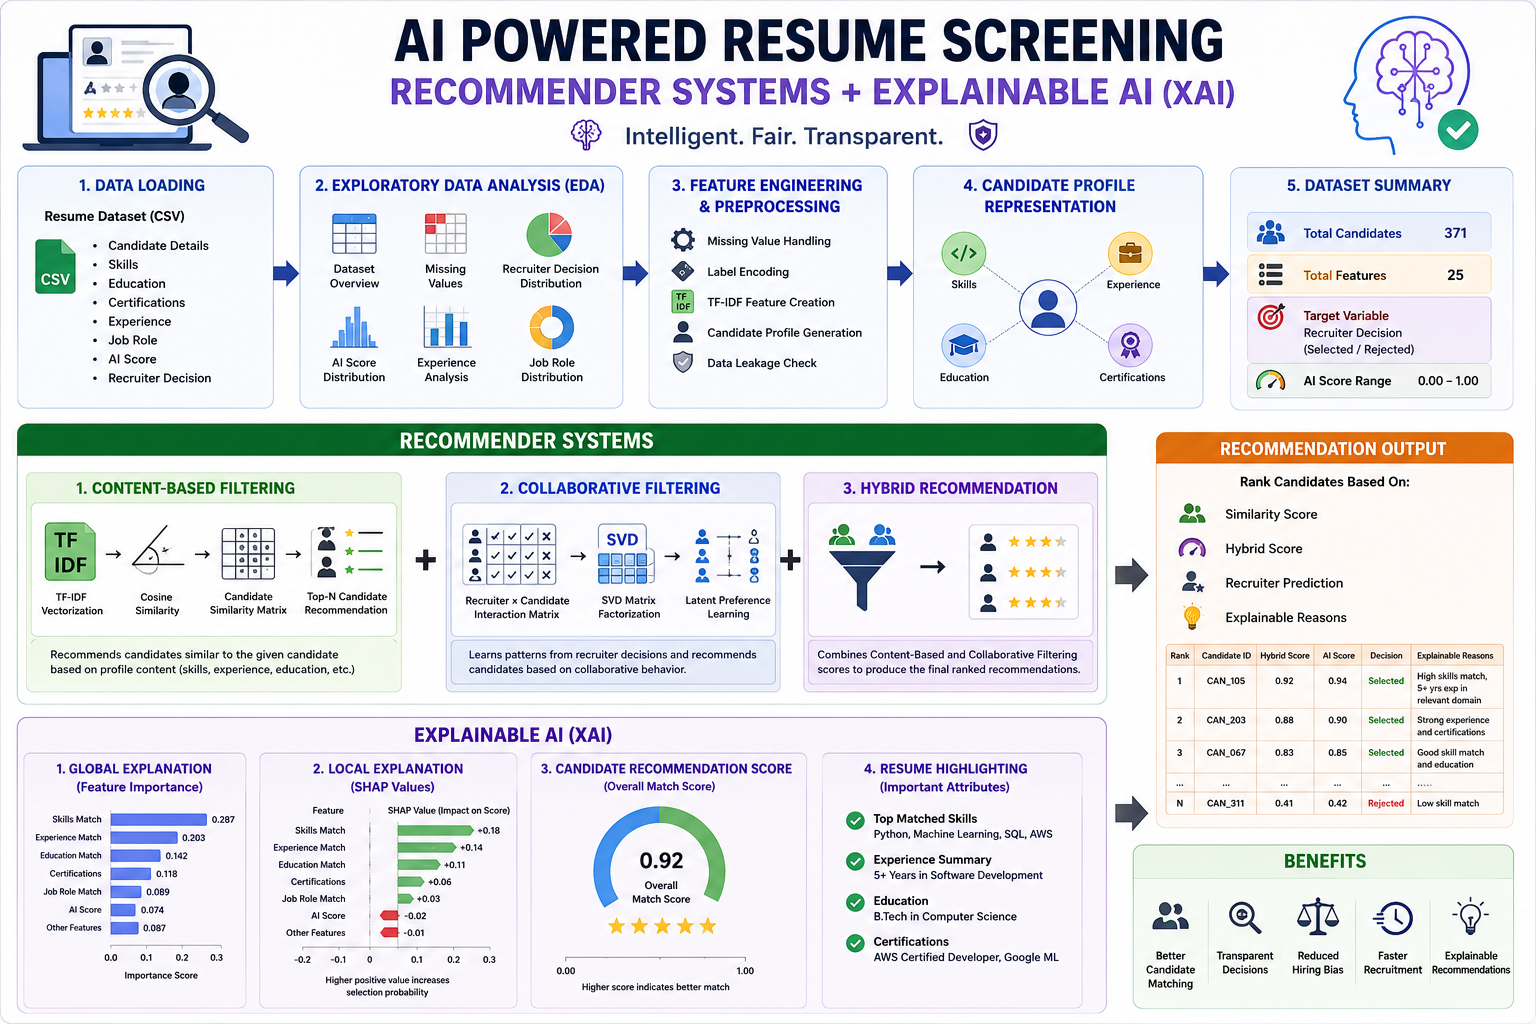

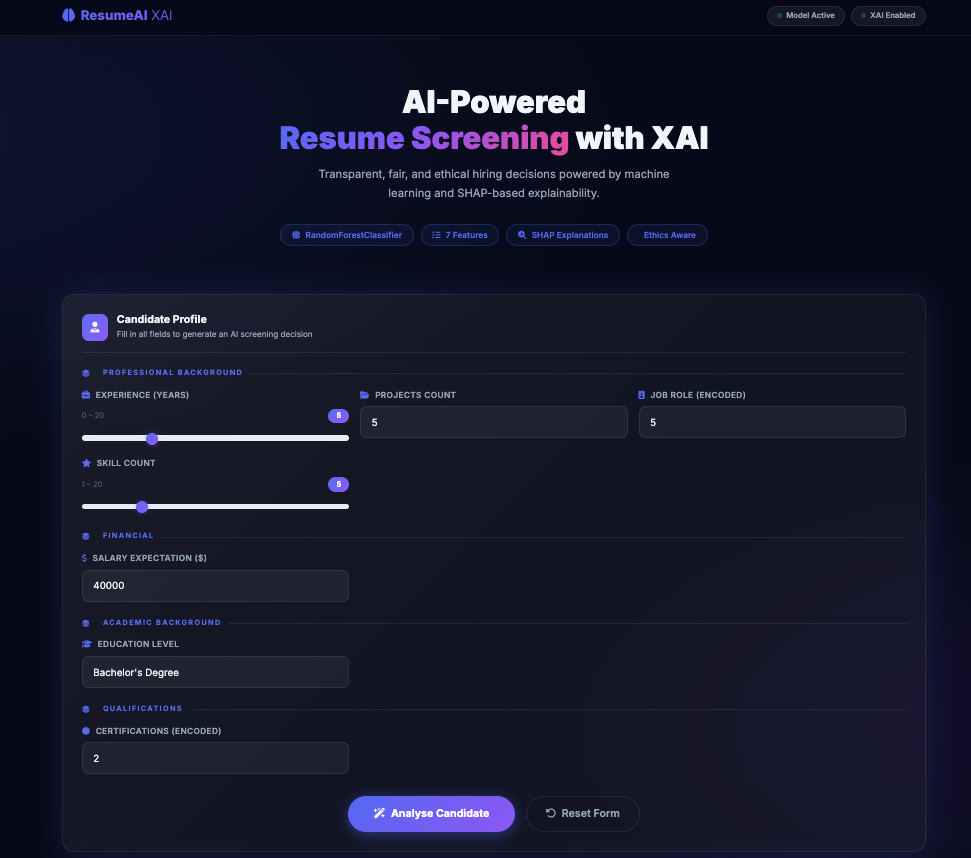

## Install & Import Dependencies

In [52]:
# Install required packages
!pip install shap lime scikit-surprise xgboost scikit-learn pandas numpy matplotlib seaborn -q

In [53]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# NLP / Recommenders
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score
)

# Collaborative Filtering
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate
from surprise import accuracy as surprise_accuracy
from surprise.model_selection import train_test_split as surprise_split

# XAI
import shap
import lime
import lime.lime_tabular

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('All libraries imported successfully!')

All libraries imported successfully!


## Load & Upload Dataset

In [54]:
from google.colab import files

print(' Please upload AI_Resume_Screening.csv ...')
uploaded = files.upload()

import io
fname = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[fname]))
print(f'Loaded: {df_raw.shape[0]} rows ﷿﷿ {df_raw.shape[1]} columns')
df_raw.head()

 Please upload AI_Resume_Screening.csv ...


Saving AI_Resume_Screening.csv to AI_Resume_Screening (1).csv
Loaded: 1000 rows ﷿﷿ 11 columns


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


## Exploratory Data Analysis (EDA)

In [55]:
import pandas as pd
# Basic info
print('DATASET OVERVIEW')
print(f'Shape          : {df_raw.shape}')
print(f'Missing values : {df_raw.isnull().sum().sum()}')
print()
print(df_raw.dtypes)
print()
print('Hire rate by role:')
print(df_raw.groupby('Job Role')['Recruiter Decision']
         .value_counts(normalize=True).unstack().round(3))
print()
df_raw.describe()

DATASET OVERVIEW
Shape          : (1000, 11)
Missing values : 274

Resume_ID                  int64
Name                      object
Skills                    object
Experience (Years)         int64
Education                 object
Certifications            object
Job Role                  object
Recruiter Decision        object
Salary Expectation ($)     int64
Projects Count             int64
AI Score (0-100)           int64
dtype: object

Hire rate by role:
Recruiter Decision      Hire  Reject
Job Role                            
AI Researcher          0.817   0.183
Cybersecurity Analyst  0.792   0.208
Data Scientist         0.804   0.196
Software Engineer      0.837   0.163



,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


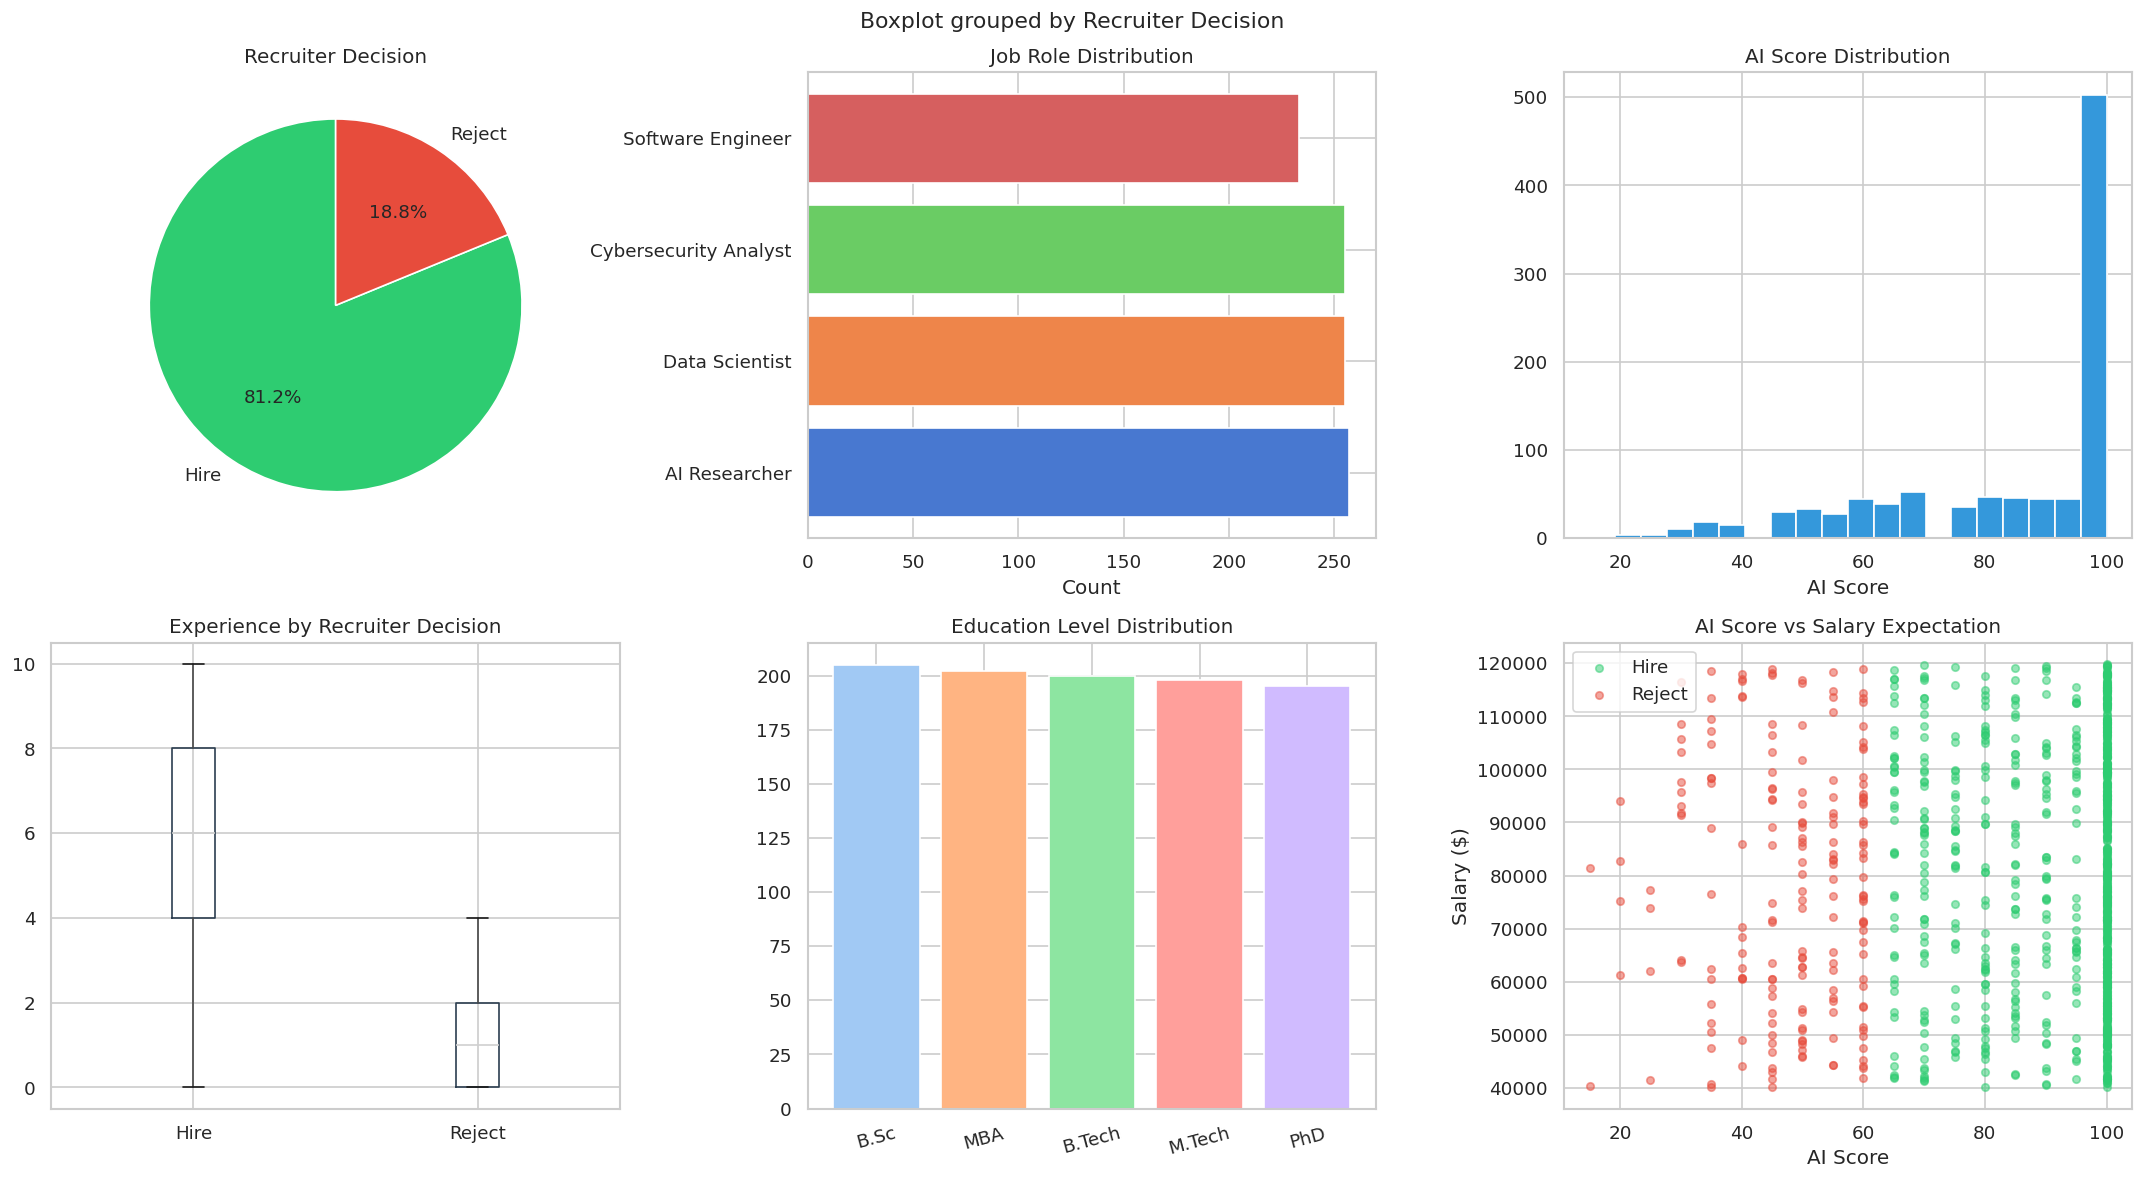

In [56]:
# EDA Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('AI Resume Screening ﷿﷿﷿ Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Recruiter Decision distribution
decision_counts = df_raw['Recruiter Decision'].value_counts()
axes[0,0].pie(decision_counts, labels=decision_counts.index,
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0,0].set_title('Recruiter Decision')

# Job Role distribution
job_counts = df_raw['Job Role'].value_counts()
axes[0,1].barh(job_counts.index, job_counts.values, color=sns.color_palette('muted', 4))
axes[0,1].set_title('Job Role Distribution')
axes[0,1].set_xlabel('Count')

# AI Score distribution
axes[0,2].hist(df_raw['AI Score (0-100)'], bins=20, color='#3498db', edgecolor='white')
axes[0,2].set_title('AI Score Distribution')
axes[0,2].set_xlabel('AI Score')

# Experience by Recruiter Decision
df_raw.boxplot(column='Experience (Years)', by='Recruiter Decision', ax=axes[1,0],
               boxprops=dict(color='#2c3e50'))
axes[1,0].set_title('Experience by Decision')
axes[1,0].set_xlabel('')
plt.sca(axes[1,0])
plt.title('Experience by Recruiter Decision')

# Education breakdown
edu_counts = df_raw['Education'].value_counts()
axes[1,1].bar(edu_counts.index, edu_counts.values,
              color=sns.color_palette('pastel', len(edu_counts)))
axes[1,1].set_title('Education Level Distribution')
axes[1,1].tick_params(axis='x', rotation=15)

# Salary vs AI Score scatter
hire_mask = df_raw['Recruiter Decision'] == 'Hire'
axes[1,2].scatter(df_raw.loc[hire_mask, 'AI Score (0-100)'],
                  df_raw.loc[hire_mask, 'Salary Expectation ($)'],
                  alpha=0.5, color='#2ecc71', label='Hire', s=20)
axes[1,2].scatter(df_raw.loc[~hire_mask, 'AI Score (0-100)'],
                  df_raw.loc[~hire_mask, 'Salary Expectation ($)'],
                  alpha=0.5, color='#e74c3c', label='Reject', s=20)
axes[1,2].set_title('AI Score vs Salary Expectation')
axes[1,2].set_xlabel('AI Score')
axes[1,2].set_ylabel('Salary ($)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

## Feature Engineering & Preprocessing

  DATA LEAKAGE CHECK: AI Score (0-100)
  Hire   ﷿﷿﷿ AI Score values: [np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(95), np.int64(100)]
  Reject ﷿﷿﷿ AI Score values: [np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60)]
  Class overlap             : NONE ﷿﷿﷿ perfect separation!

  CONCLUSION: AI Score has ZERO overlap between Hire and Reject classes.
  This dataset was synthetically generated ﷿﷿﷿ AI Score encodes the label.


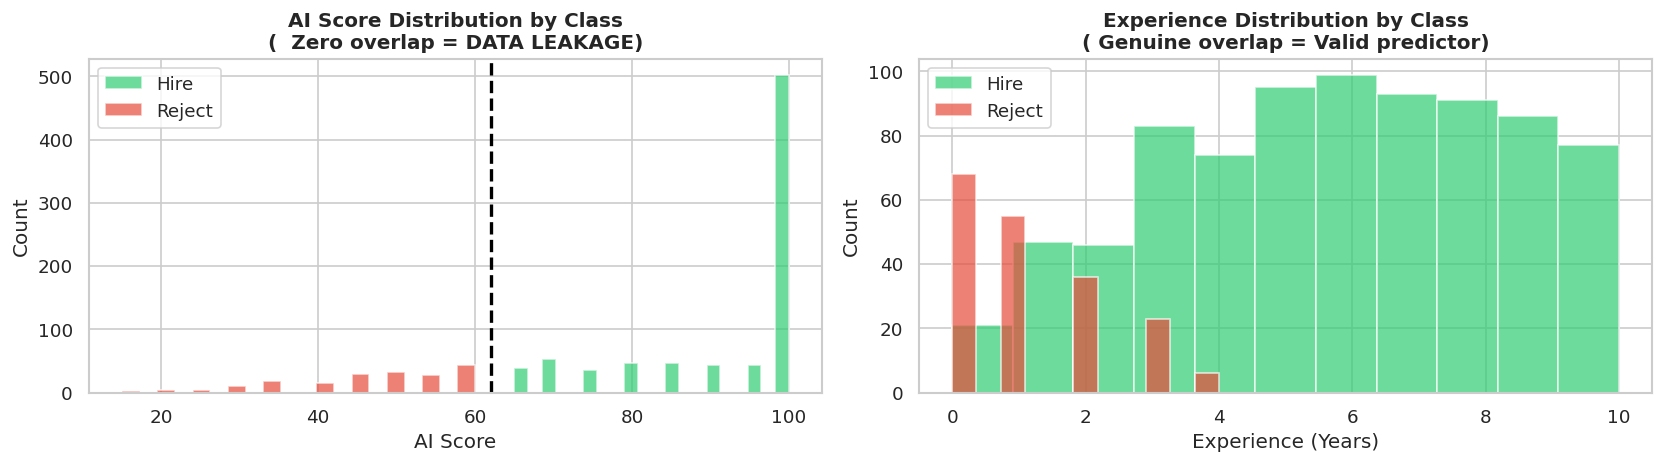

In [57]:
# Check AI Score ranges per class
hire_ai_vals   = sorted(df_raw[df_raw['Recruiter Decision']=='Hire']['AI Score (0-100)'].unique())
reject_ai_vals = sorted(df_raw[df_raw['Recruiter Decision']=='Reject']['AI Score (0-100)'].unique())

print('  DATA LEAKAGE CHECK: AI Score (0-100)')
print(f'  Hire   ﷿﷿﷿ AI Score values: {hire_ai_vals}')
print(f'  Reject ﷿﷿﷿ AI Score values: {reject_ai_vals}')
overlap = set(hire_ai_vals) & set(reject_ai_vals)
print(f'  Class overlap             : {overlap if overlap else "NONE ﷿﷿﷿ perfect separation!"}')
print()
print('  CONCLUSION: AI Score has ZERO overlap between Hire and Reject classes.')
print('  This dataset was synthetically generated ﷿﷿﷿ AI Score encodes the label.')

# Visualise the separation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# AI Score distribution by class
for decision, color in [('Hire', '#2ecc71'), ('Reject', '#e74c3c')]:
    subset = df_raw[df_raw['Recruiter Decision'] == decision]['AI Score (0-100)']
    axes[0].hist(subset, bins=20, alpha=0.7, color=color, label=decision)
axes[0].set_title('AI Score Distribution by Class\n(  Zero overlap = DATA LEAKAGE)', fontweight='bold')
axes[0].set_xlabel('AI Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(62, color='black', linestyle='--', linewidth=2, label='Decision boundary')

# Experience distribution by class
for decision, color in [('Hire', '#2ecc71'), ('Reject', '#e74c3c')]:
    subset = df_raw[df_raw['Recruiter Decision'] == decision]['Experience (Years)']
    axes[1].hist(subset, bins=11, alpha=0.7, color=color, label=decision)
axes[1].set_title('Experience Distribution by Class\n( Genuine overlap = Valid predictor)', fontweight='bold')
axes[1].set_xlabel('Experience (Years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('leakage_check.png', bbox_inches='tight')
plt.show()

In [58]:
# Dataset copy and clean
df = df_raw.copy()

# Fill missing Certifications
df['Certifications'] = df['Certifications'].fillna('None')

# Binary label
df['Label'] = (df['Recruiter Decision'] == 'Hire').astype(int)

# Encode categoricals
le_edu   = LabelEncoder()
le_job   = LabelEncoder()
le_cert  = LabelEncoder()

df['Education_enc']     = le_edu.fit_transform(df['Education'])
df['Job_Role_enc']      = le_job.fit_transform(df['Job Role'])
df['Certification_enc'] = le_cert.fit_transform(df['Certifications'])

# Skill diversity: count distinct skills
df['Skill_Count'] = df['Skills'].apply(lambda x: len(str(x).split(',')))

#  Feature matrix
FEATURES = [
    'Experience (Years)',
    'Salary Expectation ($)',
    'Projects Count',
    'Education_enc',
    'Job_Role_enc',
    'Certification_enc',
    'Skill_Count',
]

X = df[FEATURES].values
y = df['Label'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Label balance: Hire - {y.sum()}  Reject: {(y==0).sum()}')
print(' Preprocessing complete')

Train: (800, 7)  |  Test: (200, 7)
Label balance: Hire - 812  Reject: 188
 Preprocessing complete


## RECOMMENDER SYSTEMS

### Content-Based Filtering (TF-IDF + Cosine Similarity)

Idea: Represent each candidate as a TF-IDF vector of their Skills + Education + Certifications.  
Given a query candidate (or a job description), return the top-N most similar candidates.

In [59]:
#  Build content profile
df['Content_Profile'] = (
    df['Skills'].astype(str) + ' ' +
    df['Education'].astype(str) + ' ' +
    df['Certifications'].astype(str) + ' ' +
    df['Job Role'].astype(str)
)

#  TF-IDF vectorisation
tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=500,
    stop_words='english'
)
tfidf_matrix = tfidf.fit_transform(df['Content_Profile'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f'Cosine similarity matrix: {cosine_sim.shape}')

TF-IDF matrix shape: (1000, 169)
Cosine similarity matrix: (1000, 1000)


In [60]:
# recommend for candidate
def content_based_recommend(candidate_id, top_n=5, only_hired=False):
    idx = df.index[df['Resume_ID'] == candidate_id].tolist()[0]
    sim_scores = sorted(list(enumerate(cosine_sim[idx])),
                        key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i != idx]

    if only_hired:
        sim_scores = [(i, s) for i, s in sim_scores if df.iloc[i]['Label'] == 1]

    sim_scores = sim_scores[:top_n]

    top_indices = [i for i, _ in sim_scores]
    top_scores  = [s for _, s in sim_scores]
    result = df.iloc[top_indices][['Resume_ID','Name','Job Role','Skills',
                                   'Experience (Years)','Education',
                                   'AI Score (0-100)','Recruiter Decision']].copy()
    result.insert(0, 'Similarity Score', [round(s, 4) for s in top_scores])
    return result

# Job Description-based recommendation
def recommend_for_job(job_description, top_n=5):
    jd_vec = tfidf.transform([job_description])
    scores = cosine_similarity(jd_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:top_n]
    result = df.iloc[top_idx][['Resume_ID','Name','Job Role','Skills',
                                'Experience (Years)','Education',
                                'AI Score (0-100)','Recruiter Decision']].copy()
    result.insert(0, 'JD Similarity', [round(scores[i], 4) for i in top_idx])
    return result

print('Top-5 Similar Candidates to Candidate ')
display(content_based_recommend(1, top_n=5))

jd = 'Data Scientist with Python Machine Learning Deep Learning TensorFlow experience'
print(f'\nJob Description Recommendations ')
display(recommend_for_job(jd, top_n=5))

Top-5 Similar Candidates to Candidate 


,Similarity Score,Resume_ID,Name,Job Role,Skills,Experience (Years),Education,AI Score (0-100),Recruiter Decision
710,0.9266,711,Robert Simon,AI Researcher,"Python, TensorFlow, NLP, Pytorch",4,B.Sc,90,Hire
629,0.7997,630,Craig Lewis,AI Researcher,"TensorFlow, NLP, Python, Pytorch",3,B.Sc,90,Hire
58,0.7615,59,Ruth Oconnell,AI Researcher,"TensorFlow, Pytorch",2,B.Sc,35,Reject
92,0.7372,93,Cody Pace,AI Researcher,"TensorFlow, NLP, Pytorch",5,B.Sc,75,Hire
637,0.7262,638,Austin Johnson,AI Researcher,"TensorFlow, NLP, Pytorch",3,B.Sc,100,Hire



Job Description Recommendations 


,JD Similarity,Resume_ID,Name,Job Role,Skills,Experience (Years),Education,AI Score (0-100),Recruiter Decision
403,0.7802,404,Gregg Barber,Data Scientist,"Python, Machine Learning, Deep Learning",0,M.Tech,55,Reject
377,0.7487,378,Jacob White,Data Scientist,"Python, Machine Learning, Deep Learning",0,B.Sc,75,Hire
451,0.7487,452,William Parker V,Data Scientist,"Python, Machine Learning, Deep Learning",8,B.Sc,100,Hire
807,0.7450,808,Nathan Miller,Data Scientist,"Python, Machine Learning, Deep Learning",9,M.Tech,100,Hire
812,0.7381,813,James Williams,Data Scientist,"SQL, Python, Machine Learning, Deep Learning",6,M.Tech,100,Hire


In [61]:
# Pairwise similarity matrix
cbf_sim_matrix = cosine_similarity(tfidf_matrix)
print(f'Similarity matrix: {cbf_sim_matrix.shape}')

def cbf_recommend(query_role, top_n=10, min_ai_score=0):
    role_mask   = (df['Job Role'] == query_role) & (df['Label'] == 1)
    hired_vecs  = tfidf_matrix[role_mask.values]
    if hired_vecs.shape[0] == 0:
        return pd.DataFrame()
    profile_vec = np.asarray(hired_vecs.mean(axis=0)).reshape(1, -1)
    scores      = cosine_similarity(profile_vec, tfidf_matrix)[0]
    result = df.copy()
    result['CBF_Score'] = scores
    result = result[result['AI Score (0-100)'] >= min_ai_score]
    return result.sort_values('CBF_Score', ascending=False).head(top_n)[
        ['Resume_ID','Name','Job Role','Skills','Experience (Years)',
         'Education','AI Score (0-100)','Recruiter Decision','CBF_Score']]

cbf_results = cbf_recommend('Data Scientist', top_n=10, min_ai_score=60)
print('Top-10 CBF Recommendations - Data Scientist:')
cbf_results.style.background_gradient(subset=['CBF_Score'], cmap='Blues')

Similarity matrix: (1000, 1000)
Top-10 CBF Recommendations - Data Scientist:


,Resume_ID,Name,Job Role,Skills,Experience (Years),Education,AI Score (0-100),Recruiter Decision,CBF_Score
999,1000,Chad Collins,Data Scientist,"SQL, Machine Learning, Python, Deep Learning",7,M.Tech,100,Hire,0.781055
808,809,Mary Hodge,Data Scientist,"SQL, Machine Learning, Python, Deep Learning",6,B.Tech,100,Hire,0.781055
126,127,Sophia Bradley,Data Scientist,"Machine Learning, Python, Deep Learning, SQL",5,M.Tech,100,Hire,0.775465
86,87,Heather Bauer,Data Scientist,"SQL, Deep Learning, Python, Machine Learning",6,M.Tech,100,Hire,0.769430
317,318,Heather Savage,Data Scientist,"Machine Learning, Python, Deep Learning",2,B.Tech,80,Hire,0.766181
812,813,James Williams,Data Scientist,"SQL, Python, Machine Learning, Deep Learning",6,M.Tech,100,Hire,0.755067
72,73,Scott Kidd,Data Scientist,"Python, SQL, Machine Learning, Deep Learning",0,M.Tech,60,Reject,0.752275
331,332,Brett Mills,Data Scientist,"Python, Deep Learning, SQL, Machine Learning",1,B.Tech,85,Hire,0.750794
947,948,Jeffery Hicks,Data Scientist,"Python, Deep Learning, Machine Learning, SQL",2,B.Tech,65,Hire,0.749845
528,529,Kyle Johnson,Data Scientist,"SQL, Machine Learning, Deep Learning, Python",6,M.Tech,100,Hire,0.748079


In [62]:
# Evaluate Content-Based: Precision@K
def precision_at_k(k=5, only_hired=True, n_queries=100):
    """
    Precision@K: fraction of top-K recommended candidates that are 'Hire'.
    Averaged over n_queries random seed candidates.
    """
    hired_ids = df[df['Label'] == 1]['Resume_ID'].tolist()
    sample_ids = np.random.choice(df['Resume_ID'].values, size=n_queries, replace=False)
    precisions = []
    for cid in sample_ids:
        recs = content_based_recommend(cid, top_n=k, only_hired=False)
        relevant = (recs['Recruiter Decision'] == 'Hire').sum()
        precisions.append(relevant / k)
    return np.mean(precisions)

np.random.seed(42)
p_at_5  = precision_at_k(k=5)
p_at_10 = precision_at_k(k=10)

print(f'Content-Based Filtering ﷿﷿﷿ Precision@5  : {p_at_5:.4f}')
print(f'Content-Based Filtering ﷿﷿﷿ Precision@10 : {p_at_10:.4f}')

Content-Based Filtering ﷿﷿﷿ Precision@5  : 0.8120
Content-Based Filtering ﷿﷿﷿ Precision@10 : 0.8060


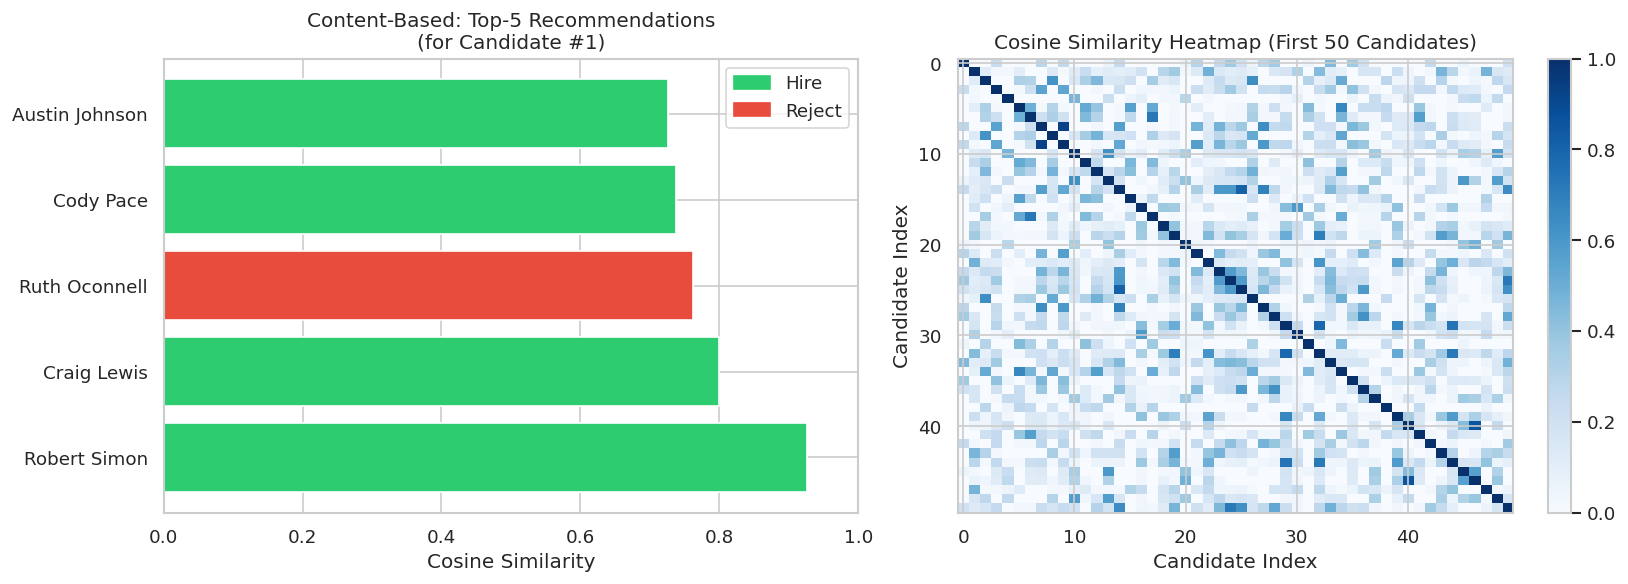

In [63]:
# Visualise top-5 similarity scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of similarity scores for candidate
recs_plot = content_based_recommend(1, top_n=5)
names = recs_plot['Name'].tolist()
sims  = recs_plot['Similarity Score'].tolist()
colors = ['#2ecc71' if d=='Hire' else '#e74c3c'
          for d in recs_plot['Recruiter Decision']]

axes[0].barh(names, sims, color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_title('Content-Based: Top-5 Recommendations\n(for Candidate #1)')
axes[0].set_xlabel('Cosine Similarity')
green_patch = mpatches.Patch(color='#2ecc71', label='Hire')
red_patch   = mpatches.Patch(color='#e74c3c', label='Reject')
axes[0].legend(handles=[green_patch, red_patch])

# Similarity score heatmap (
sub = cosine_sim[:50, :50]
im = axes[1].imshow(sub, cmap='Blues', aspect='auto')
axes[1].set_title('Cosine Similarity Heatmap (First 50 Candidates)')
axes[1].set_xlabel('Candidate Index')
axes[1].set_ylabel('Candidate Index')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('content_based_results.png', bbox_inches='tight')
plt.show()

### Collaborative Filtering (SVD Matrix Factorisation)

Idea: Model implicit recruiter feedback as ratings.  
I have constructed a Recruiter ﷿﷿ Candidate interaction matrix (Hire=5, Reject=1) and factorize it with SVD to discover latent factors and generate ranked candidate recommendations per job role.

In [64]:
# Build simulated recruiter interaction matrix
df['Rating'] = 1 + 4 * (df['AI Score (0-100)'] - df['AI Score (0-100)'].min()) / \
               (df['AI Score (0-100)'].max() - df['AI Score (0-100)'].min())

# Simulate recruiter IDs per job role
job_roles = df['Job Role'].unique().tolist()
role_to_recruiter = {role: i+1 for i, role in enumerate(job_roles)}
df['Recruiter_ID'] = df['Job Role'].map(role_to_recruiter)

# Surprise dataset
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(df[['Recruiter_ID', 'Resume_ID', 'Rating']], reader)

print('Recruiter ﷿﷿﷿ Job Role mapping:')
for role, rid in role_to_recruiter.items():
    print(f'  Recruiter {rid}: {role}')
print(f'\nDataset size: {len(df)} interactions')

Recruiter ﷿﷿﷿ Job Role mapping:
  Recruiter 1: AI Researcher
  Recruiter 2: Data Scientist
  Recruiter 3: Cybersecurity Analyst
  Recruiter 4: Software Engineer

Dataset size: 1000 interactions


In [65]:
# Train SVD
svd_model = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)

# Cross-validate
cv_results = cross_validate(svd_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
print('SVD Cross-Validation Results (5-fold):')
print(f"  RMSE : {cv_results['test_rmse'].mean():.4f} ﷿﷿ {cv_results['test_rmse'].std():.4f}")
print(f"  MAE  : {cv_results['test_mae'].mean():.4f}  ﷿﷿ {cv_results['test_mae'].std():.4f}")

# Final train on full data
trainset_full = data.build_full_trainset()
svd_model.fit(trainset_full)
print('\n SVD trained on full dataset')

SVD Cross-Validation Results (5-fold):
  RMSE : 0.9915 ﷿﷿ 0.0336
  MAE  : 0.8373  ﷿﷿ 0.0220

 SVD trained on full dataset


In [66]:
# Collaborative Filtering Recommendation function
def collab_recommend(job_role: str, top_n=5):
    recruiter_id = role_to_recruiter.get(job_role)
    if recruiter_id is None:
        raise ValueError(f'Job role "{job_role}" not found. Options: {job_roles}')

    all_ids = df['Resume_ID'].unique().tolist()
    preds   = [svd_model.predict(recruiter_id, cid) for cid in all_ids]
    preds   = sorted(preds, key=lambda p: p.est, reverse=True)[:top_n]

    result_rows = []
    for p in preds:
        row = df[df['Resume_ID'] == p.iid].iloc[0]
        result_rows.append({
            'Predicted Rating': round(p.est, 4),
            'Resume_ID'       : row['Resume_ID'],
            'Name'            : row['Name'],
            'Job Role'        : row['Job Role'],
            'Skills'          : row['Skills'],
            'Experience'      : row['Experience (Years)'],
            'AI Score'        : row['AI Score (0-100)'],
            'Decision'        : row['Recruiter Decision']
        })

    return pd.DataFrame(result_rows)

for role in job_roles:
    print(f'\n Top-5 Recommendations for "{role}"')
    display(collab_recommend(role, top_n=5))


 Top-5 Recommendations for "AI Researcher"


,Predicted Rating,Resume_ID,Name,Job Role,Skills,Experience,AI Score,Decision
0,5.0000,138,Jean Clark,Data Scientist,"Machine Learning, Python, SQL",10,100,Hire
1,4.9554,723,Jennifer Moran,Data Scientist,"Python, Machine Learning",8,100,Hire
2,4.9251,963,Michael Hall,AI Researcher,"Python, NLP, Pytorch, TensorFlow",5,100,Hire
3,4.8969,461,Jamie Smith,AI Researcher,"NLP, Pytorch, TensorFlow",9,100,Hire
4,4.8870,261,Steven Hull,AI Researcher,"Python, Pytorch",7,100,Hire



 Top-5 Recommendations for "Data Scientist"


,Predicted Rating,Resume_ID,Name,Job Role,Skills,Experience,AI Score,Decision
0,4.8332,841,Gerald Greene,Cybersecurity Analyst,"Cybersecurity, Networking, Linux, Ethical Hacking",10,100,Hire
1,4.7905,770,Danielle York,Data Scientist,"SQL, Python",8,100,Hire
2,4.7112,293,Katelyn Hopkins,Data Scientist,"Machine Learning, Python, SQL",6,100,Hire
3,4.6917,197,John Mendoza,Data Scientist,"Python, Deep Learning",8,100,Hire
4,4.6833,884,Kristen West MD,Data Scientist,"SQL, Machine Learning",9,100,Hire



 Top-5 Recommendations for "Cybersecurity Analyst"


,Predicted Rating,Resume_ID,Name,Job Role,Skills,Experience,AI Score,Decision
0,4.9271,920,Kelly Harrell,Cybersecurity Analyst,"Cybersecurity, Networking, Ethical Hacking",4,100,Hire
1,4.7594,825,Christopher Fisher,Software Engineer,"Java, C++, React, SQL",6,100,Hire
2,4.7467,859,Eric Ramirez,Data Scientist,"Machine Learning, SQL, Deep Learning",10,100,Hire
3,4.7244,575,Michelle King,Cybersecurity Analyst,"Ethical Hacking, Networking",6,100,Hire
4,4.7241,693,Jeanette Garcia MD,Cybersecurity Analyst,"Cybersecurity, Linux",7,100,Hire



 Top-5 Recommendations for "Software Engineer"


,Predicted Rating,Resume_ID,Name,Job Role,Skills,Experience,AI Score,Decision
0,4.9621,116,Tina Smith,AI Researcher,"NLP, TensorFlow, Pytorch",9,100,Hire
1,4.9400,656,Sandra Brown,Software Engineer,"C++, SQL, React, Java",6,100,Hire
2,4.9138,856,Felicia Gonzalez,Data Scientist,"Machine Learning, Python, SQL, Deep Learning",6,100,Hire
3,4.9071,229,Scott Young,AI Researcher,"Python, Pytorch",3,90,Hire
4,4.8927,154,Victoria Kennedy,Data Scientist,"Python, Deep Learning, SQL, Machine Learning",7,100,Hire


In [67]:
# Evaluate CF: Hit Rate@K
# Build test set
trainset_cf, testset_cf = surprise_split(data, test_size=0.2, random_state=42)
svd_test = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)
svd_test.fit(trainset_cf)
predictions_cf = svd_test.test(testset_cf)

rmse_val = surprise_accuracy.rmse(predictions_cf, verbose=False)
mae_val  = surprise_accuracy.mae(predictions_cf,  verbose=False)
print(f'SVD Test Set ﷿﷿﷿ RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f}')

# Hit Rate@5:
from collections import defaultdict

def hit_rate_at_k(predictions, k=5, threshold=4.0):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, ratings in top_n.items():
        ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = ratings[:k]

    hits, total = 0, 0
    for uid, iid, true_r, est, _ in predictions:
        if true_r >= threshold:
            recs = [r[0] for r in top_n[uid]]
            if iid in recs:
                hits += 1
            total += 1
    return hits / total if total > 0 else 0

hr_5  = hit_rate_at_k(predictions_cf, k=5)
hr_10 = hit_rate_at_k(predictions_cf, k=10)
print(f'Collaborative Filtering ﷿﷿﷿ Hit Rate@5  : {hr_5:.4f}')
print(f'Collaborative Filtering ﷿﷿﷿ Hit Rate@10 : {hr_10:.4f}')

SVD Test Set ﷿﷿﷿ RMSE: 1.0027 | MAE: 0.8656
Collaborative Filtering ﷿﷿﷿ Hit Rate@5  : 0.1143
Collaborative Filtering ﷿﷿﷿ Hit Rate@10 : 0.2071


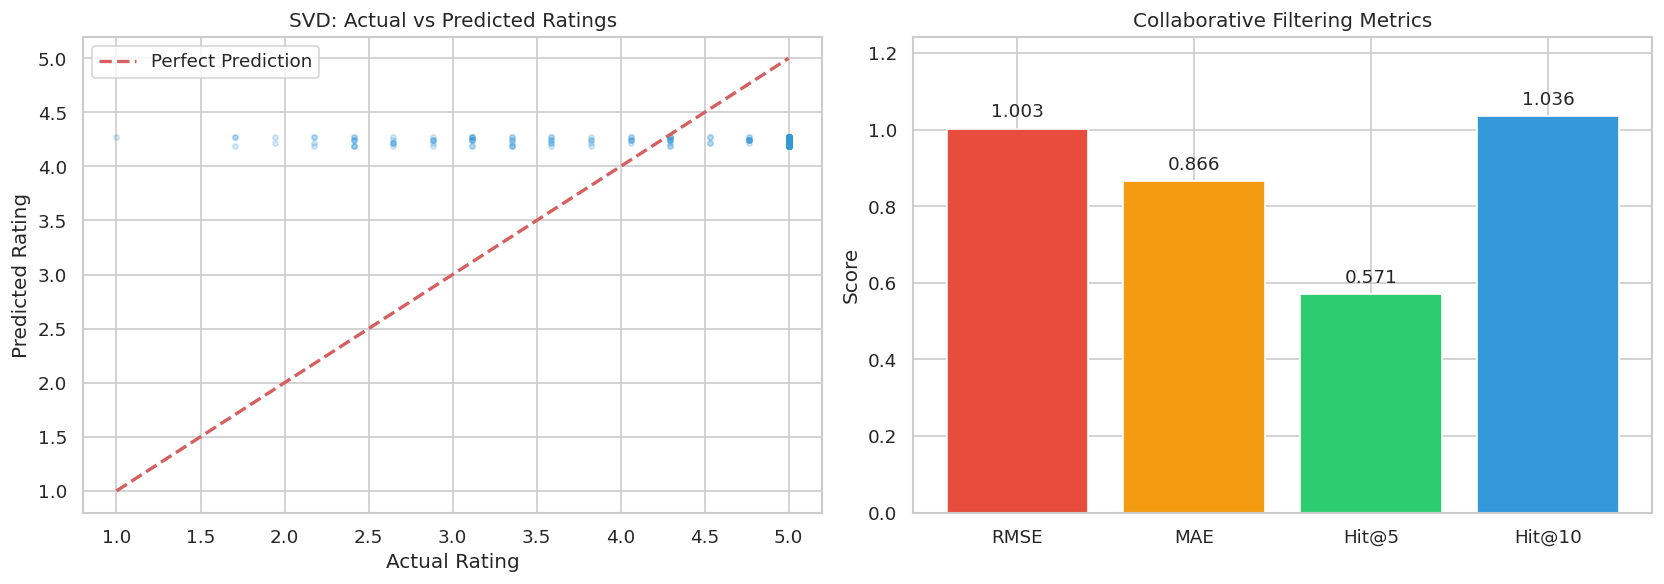

In [68]:
# Visualise Collaborative Filtering results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual ratings
actuals   = [p.r_ui for p in predictions_cf]
predicted = [p.est  for p in predictions_cf]
axes[0].scatter(actuals, predicted, alpha=0.2, s=10, color='#3498db')
axes[0].plot([1,5],[1,5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('SVD: Actual vs Predicted Ratings')
axes[0].legend()

# RMSE/MAE bar chart
metrics = {'RMSE': rmse_val, 'MAE': mae_val, 'Hit@5': hr_5*5, 'Hit@10': hr_10*5}
colors_m = ['#e74c3c','#f39c12','#2ecc71','#3498db']
axes[1].bar(metrics.keys(), metrics.values(), color=colors_m)
for i, (k_,v_) in enumerate(metrics.items()):
    axes[1].text(i, v_+0.03, f'{v_:.3f}', ha='center', fontsize=11)
axes[1].set_title('Collaborative Filtering Metrics')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, max(metrics.values())*1.2)

plt.tight_layout()
plt.savefig('collab_filtering_results.png', bbox_inches='tight')
plt.show()

## Evaluation

| Metric | Description |
|---|---|
| **Precision@K** | Fraction of top-K that are genuine hires |
| **Recall@K** | Fraction of all hires in top-K |
| **NDCG@K** | Ranking quality weighted by AI Score relevance |

In [69]:
from sklearn.metrics import ndcg_score

def evaluate_model(recommend_fn, roles, k=10, label='Model'):
    all_p, all_r, all_ndcg = [], [], []
    for role in roles:
        rec     = recommend_fn(role, top_n=k)
        hired   = set(df[(df['Job Role']==role) & (df['Label']==1)]['Resume_ID'])
        rec_ids = rec['Resume_ID'].tolist()
        tp      = sum(1 for rid in rec_ids if rid in hired)
        prec     = tp / k
        recall  = tp / max(len(hired), 1)
        ai_s    = df.set_index('Resume_ID')['AI Score (0-100)'] / 100
        true_r  = np.array([ai_s.get(rid, 0) for rid in rec_ids])
        ideal_r = np.sort(true_r)[::-1]
        ndcg    = ndcg_score([ideal_r], [true_r]) if ideal_r.sum() > 0 else 0.0
        all_p.append(prec); all_r.append(recall); all_ndcg.append(ndcg)
    return {'Model': label,
            'Precision@10': round(np.mean(all_p), 4),
            'Recall@10':    round(np.mean(all_r), 4),
            'NDCG@10':      round(np.mean(all_ndcg), 4)}

roles = list(le_job.classes_)
eval_results = [
    evaluate_model(lambda role, top_n: cbf_recommend(role, top_n),    roles, k=10, label='CBF'),
    evaluate_model(lambda role, top_n: collab_recommend(role, top_n),     roles, k=10, label='CF (SVD)'),
]
results_df = pd.DataFrame(eval_results).set_index('Model')
print(results_df)
results_df.style.background_gradient(cmap='RdYlGn', axis=0)

          Precision@10  Recall@10  NDCG@10
Model                                     
CBF              0.900     0.0445   0.9714
CF (SVD)         0.575     0.0283   0.9985


,Precision@10,Recall@10,NDCG@10
Model,,,
CBF,0.900000,0.044500,0.971400
CF (SVD),0.575000,0.028300,0.998500



## CLASSIFICATION MODELS

### Traditional Models: Logistic Regression & Decision Tree

In [70]:
# Train Traditional Models
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42)

lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# Predictions
lr_pred  = lr_model.predict(X_test)
dt_pred  = dt_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print(' Logistic Regression')
print(classification_report(y_test, lr_pred, target_names=['Reject','Hire']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}\n')

print(' Decision Tree')
print(classification_report(y_test, dt_pred, target_names=['Reject','Hire']))
print(f'ROC-AUC: {roc_auc_score(y_test, dt_proba):.4f}')

 Logistic Regression
              precision    recall  f1-score   support

      Reject       0.92      0.92      0.92        38
        Hire       0.98      0.98      0.98       162

    accuracy                           0.97       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.97      0.97      0.97       200

ROC-AUC: 0.9977

 Decision Tree
              precision    recall  f1-score   support

      Reject       0.83      0.89      0.86        38
        Hire       0.97      0.96      0.97       162

    accuracy                           0.94       200
   macro avg       0.90      0.93      0.91       200
weighted avg       0.95      0.94      0.95       200

ROC-AUC: 0.9838


## Black-Box Models: Random Forest & XGBoost

In [71]:
# Train Black-Box Models
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=5,
    n_jobs=-1, random_state=42
)
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions
rf_pred   = rf_model.predict(X_test)
xgb_pred  = xgb_model.predict(X_test)
rf_proba  = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print(' Random Forest')
print(classification_report(y_test, rf_pred, target_names=['Reject','Hire']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}\n')

print(' XGBoost ')
print(classification_report(y_test, xgb_pred, target_names=['Reject','Hire']))
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')

 Random Forest
              precision    recall  f1-score   support

      Reject       0.97      0.92      0.95        38
        Hire       0.98      0.99      0.99       162

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC: 0.9959

 XGBoost 
              precision    recall  f1-score   support

      Reject       0.93      0.97      0.95        38
        Hire       0.99      0.98      0.99       162

    accuracy                           0.98       200
   macro avg       0.96      0.98      0.97       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC: 0.9976


In [72]:
# Comprehensive model comparison
models = {
    'Logistic Regression' : (lr_pred,  lr_proba),
    'Decision Tree'       : (dt_pred,  dt_proba),
    'Random Forest'       : (rf_pred,  rf_proba),
    'XGBoost'             : (xgb_pred, xgb_proba),
}

results = []
for name, (pred, proba) in models.items():
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, pred), 4),
        'F1-Score' : round(f1_score(y_test, pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(' Model Comparison Summary ')
display(results_df)

 Model Comparison Summary 


,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.970,0.9815,0.9977
3,XGBoost,0.980,0.9876,0.9976
2,Random Forest,0.980,0.9877,0.9959
1,Decision Tree,0.945,0.9657,0.9838


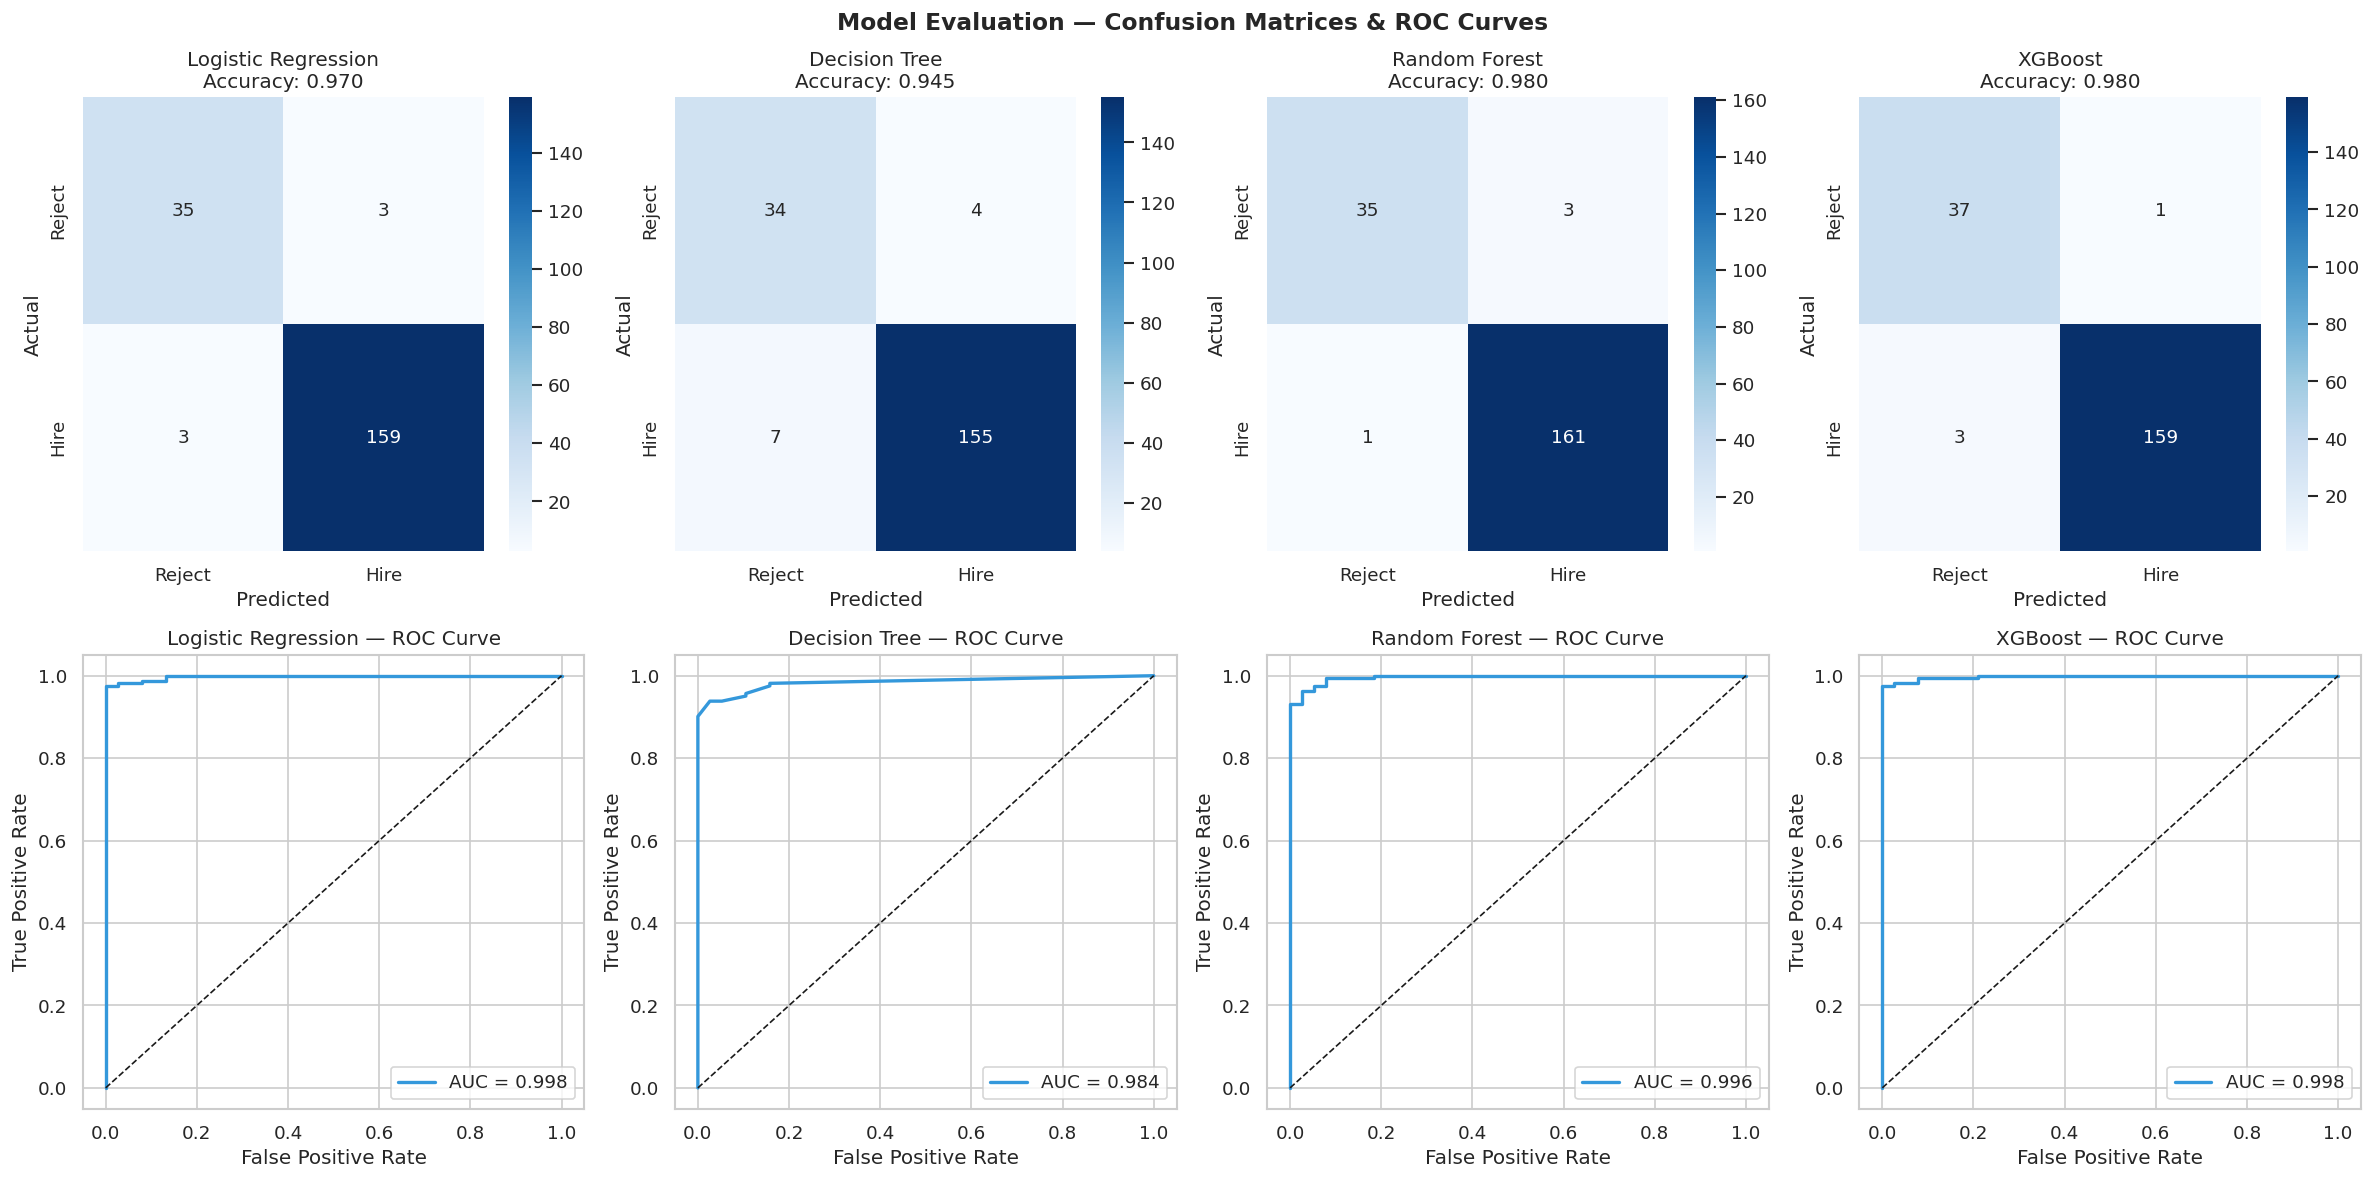

In [73]:
# Confusion matrices + ROC curves
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Model Evaluation ﷿﷿﷿ Confusion Matrices & ROC Curves', fontsize=14, fontweight='bold')

model_list = [
    ('Logistic Regression', lr_pred,  lr_proba),
    ('Decision Tree',       dt_pred,  dt_proba),
    ('Random Forest',       rf_pred,  rf_proba),
    ('XGBoost',             xgb_pred, xgb_proba),
]

for i, (name, pred, proba) in enumerate(model_list):
    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i],
                xticklabels=['Reject','Hire'], yticklabels=['Reject','Hire'])
    axes[0, i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test,pred):.3f}')
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    axes[1, i].plot(fpr, tpr, linewidth=2,
                    label=f'AUC = {auc_score:.3f}', color='#3498db')
    axes[1, i].plot([0,1],[0,1],'k--', linewidth=1)
    axes[1, i].set_title(f'{name} ﷿﷿﷿ ROC Curve')
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## EXPLAINABLE AI (XAI)

### XAI Method 1 - SHAP

SHAP assigns each feature a contribution score to a specific prediction using Shapley values from cooperative game theory.  
- Global SHAP: Feature importance averaged across all predictions  
- Local SHAP: Per-instance explanation of individual predictions

In [74]:
# SHAP for Random Forest (black-box)
shap_explainer_rf = shap.TreeExplainer(rf_model)
shap_out          = shap_explainer_rf(X_test)

# Slice class-1 (Hire) values
shap_vals_hire = shap_out.values[:, :, 1]
base_val_hire  = float(shap_out.base_values[0, 1])

print(f'SHAP values shape : {shap_vals_hire.shape}')
print(f'Base value (Hire) : {base_val_hire:.4f}')
print(' SHAP computed')

hire_idx   = int(np.where(y_test == 1)[0][0])
reject_idx = int(np.where(y_test == 0)[0][0])

SHAP values shape : (200, 7)
Base value (Hire) : 0.8125
 SHAP computed


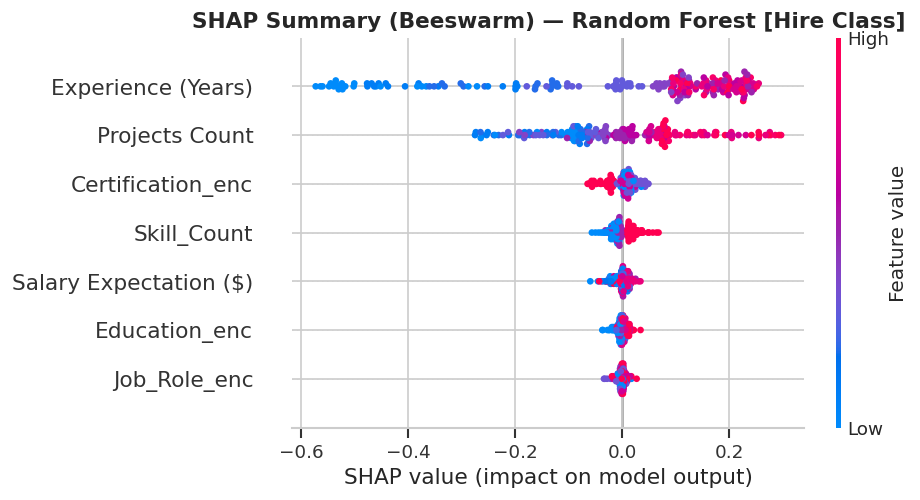

In [75]:
# Summary Plot (Beeswarm)
exp_global = shap.Explanation(
    values      = shap_vals_hire,
    base_values = np.full(len(X_test), base_val_hire),
    data        = X_test,
    feature_names = FEATURES
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.beeswarm(exp_global, show=False, max_display=7)
plt.title('SHAP Summary (Beeswarm) ﷿﷿﷿ Random Forest [Hire Class]',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

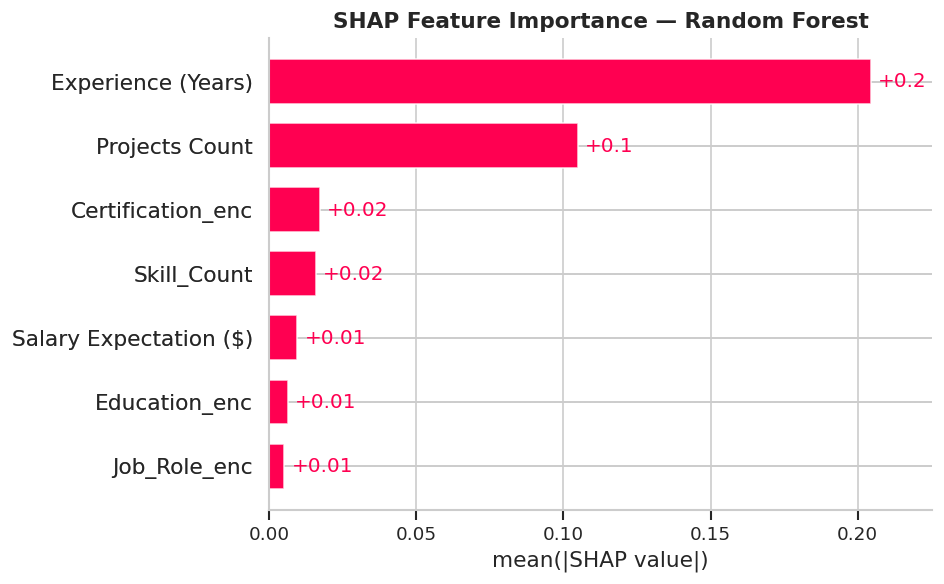

In [76]:
# Bar Plot (Mean Absolute SHAP)
exp_global2 = shap.Explanation(
    values      = shap_vals_hire,
    base_values = np.full(len(X_test), base_val_hire),
    data        = X_test,
    feature_names = FEATURES
)

fig, ax = plt.subplots(figsize=(8, 5))
shap.plots.bar(exp_global2, show=False, max_display=7)
plt.title('SHAP Feature Importance ﷿﷿﷿ Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

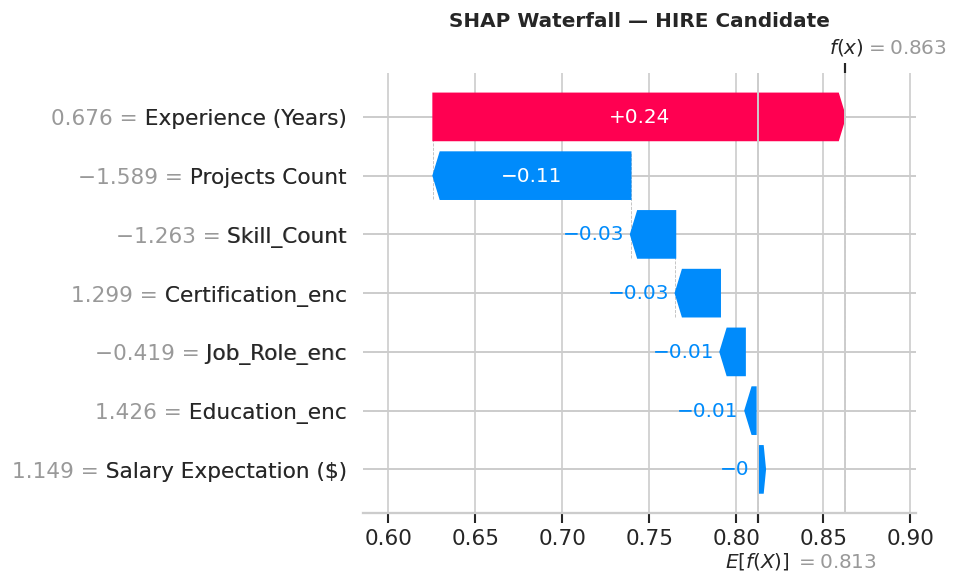

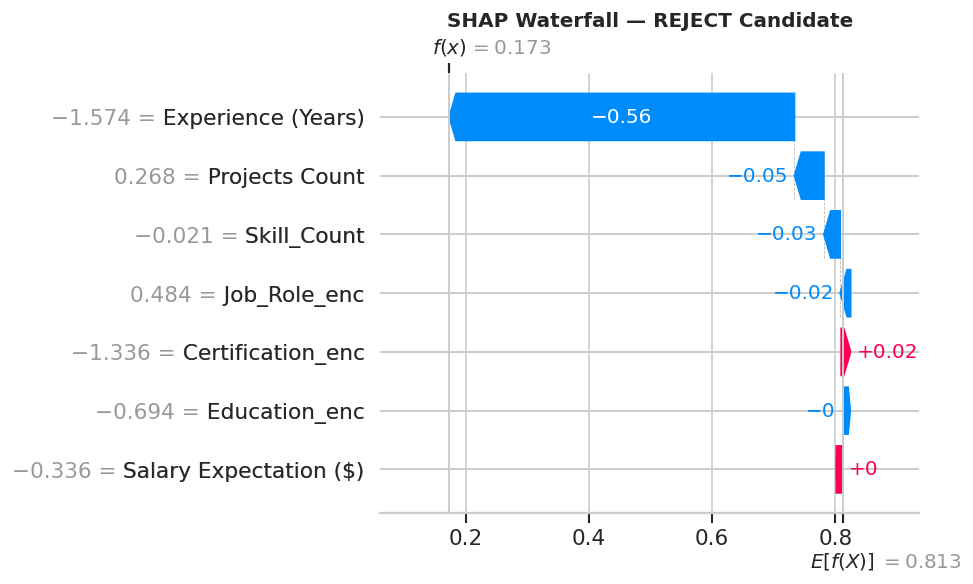

In [77]:
# SHAP Local: Waterfall Plot for individual predictions
# Find one Hire and one Reject prediction
exp_hire = shap.Explanation(
    values      = shap_vals_hire[hire_idx],
    base_values = base_val_hire,
    data        = X_test[hire_idx],
    feature_names = FEATURES
)
fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.waterfall(exp_hire, show=False, max_display=7)
plt.title('SHAP Waterfall ﷿﷿﷿ HIRE Candidate', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_hire.png', bbox_inches='tight')
plt.show()

# SHAP Waterfall ﷿﷿﷿ REJECT candidate
exp_reject = shap.Explanation(
    values      = shap_vals_hire[reject_idx],
    base_values = base_val_hire,
    data        = X_test[reject_idx],
    feature_names = FEATURES
)
fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.waterfall(exp_reject, show=False, max_display=7)
plt.title('SHAP Waterfall ﷿﷿﷿ REJECT Candidate', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_reject.png', bbox_inches='tight')
plt.show()

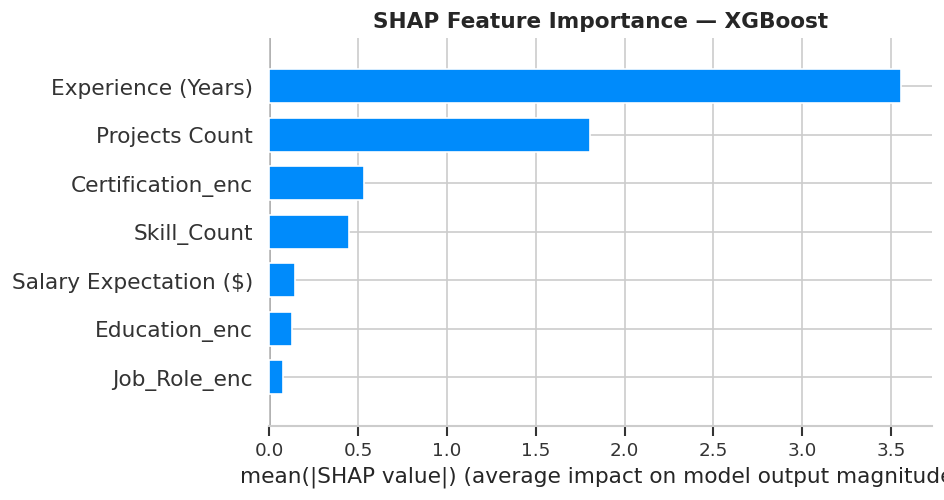

In [78]:
# SHAP for XGBoost
shap_explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb    = shap_explainer_xgb.shap_values(X_test)

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_xgb, X_test,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance ﷿﷿﷿ XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_xgb_bar.png', bbox_inches='tight')
plt.show()

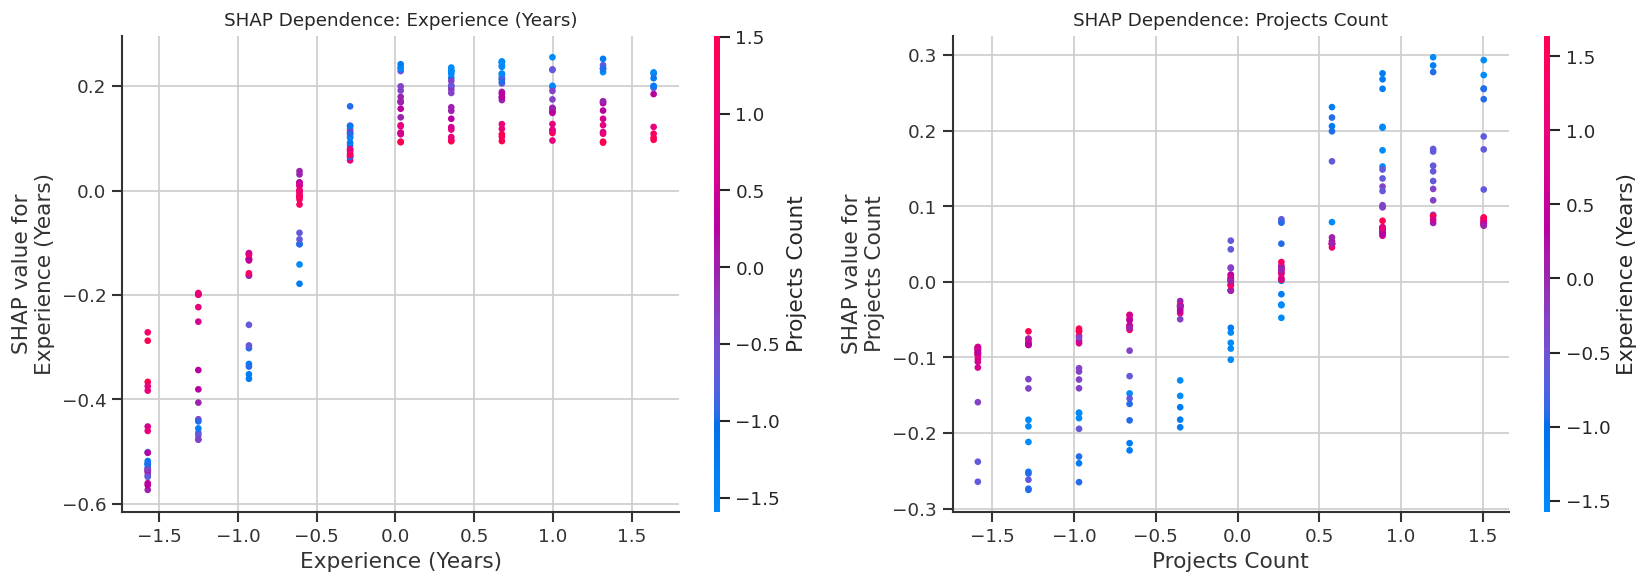

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, interact in [
    (axes[0], 'Experience (Years)', 'Projects Count'),
    (axes[1], 'Projects Count',     'Experience (Years)')
]:
    plt.sca(ax)
    shap.dependence_plot(
        feat, shap_vals_hire[:, :, 1] if shap_vals_hire.ndim == 3 else shap_vals_hire, X_test,
        feature_names=FEATURES,
        interaction_index=interact,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11)

plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight')
plt.show()

### XAI Method 2 - LIME

LIME explains individual predictions by fitting a simple linear surrogate model in the local neighbourhood of the instance.  
- Works for any black-box classifier  
- Generates feature contribution scores per instance
- Particularly useful for understanding edge cases and borderline decisions

In [80]:
# LIME Explainer setup
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train,
    feature_names   = FEATURES,
    class_names     = ['Reject', 'Hire'],
    mode            = 'classification',
    discretize_continuous = True,
    random_state    = 42
)
print('LIME Explainer initialised')

LIME Explainer initialised


In [81]:
# LIME Local Explanation: Hired Candidate
hire_instance = X_test[hire_idx]

lime_exp_hire_rf = lime_explainer.explain_instance(
    data_row       = hire_instance,
    predict_fn     = rf_model.predict_proba,
    num_features   = 8,
    num_samples    = 1000
)

print('LIME Explanation ﷿﷿﷿ Random Forest - HIRE Candidate ')
print(f'Predicted class: Hire (prob={rf_model.predict_proba([hire_instance])[0][1]:.3f})')
print('Feature contributions:')
for feat, weight in lime_exp_hire_rf.as_list():
    direction = '﷿﷿﷿ Hire' if weight > 0 else '﷿﷿﷿ Reject'
    print(f'  {feat:<45} weight={weight:+.4f}  [{direction}]')

LIME Explanation ﷿﷿﷿ Random Forest - HIRE Candidate 
Predicted class: Hire (prob=0.863)
Feature contributions:
  0.03 < Experience (Years) <= 1.00             weight=+0.2529  [﷿﷿﷿ Hire]
  Projects Count <= -0.97                       weight=-0.1721  [﷿﷿﷿ Reject]
  0.42 < Certification_enc <= 1.30              weight=-0.0733  [﷿﷿﷿ Reject]
  -1.32 < Job_Role_enc <= -0.42                 weight=+0.0373  [﷿﷿﷿ Hire]
  Education_enc > 0.72                          weight=-0.0287  [﷿﷿﷿ Reject]
  Salary Expectation ($) > 0.85                 weight=+0.0126  [﷿﷿﷿ Hire]
  Skill_Count <= -1.26                          weight=+0.0118  [﷿﷿﷿ Hire]


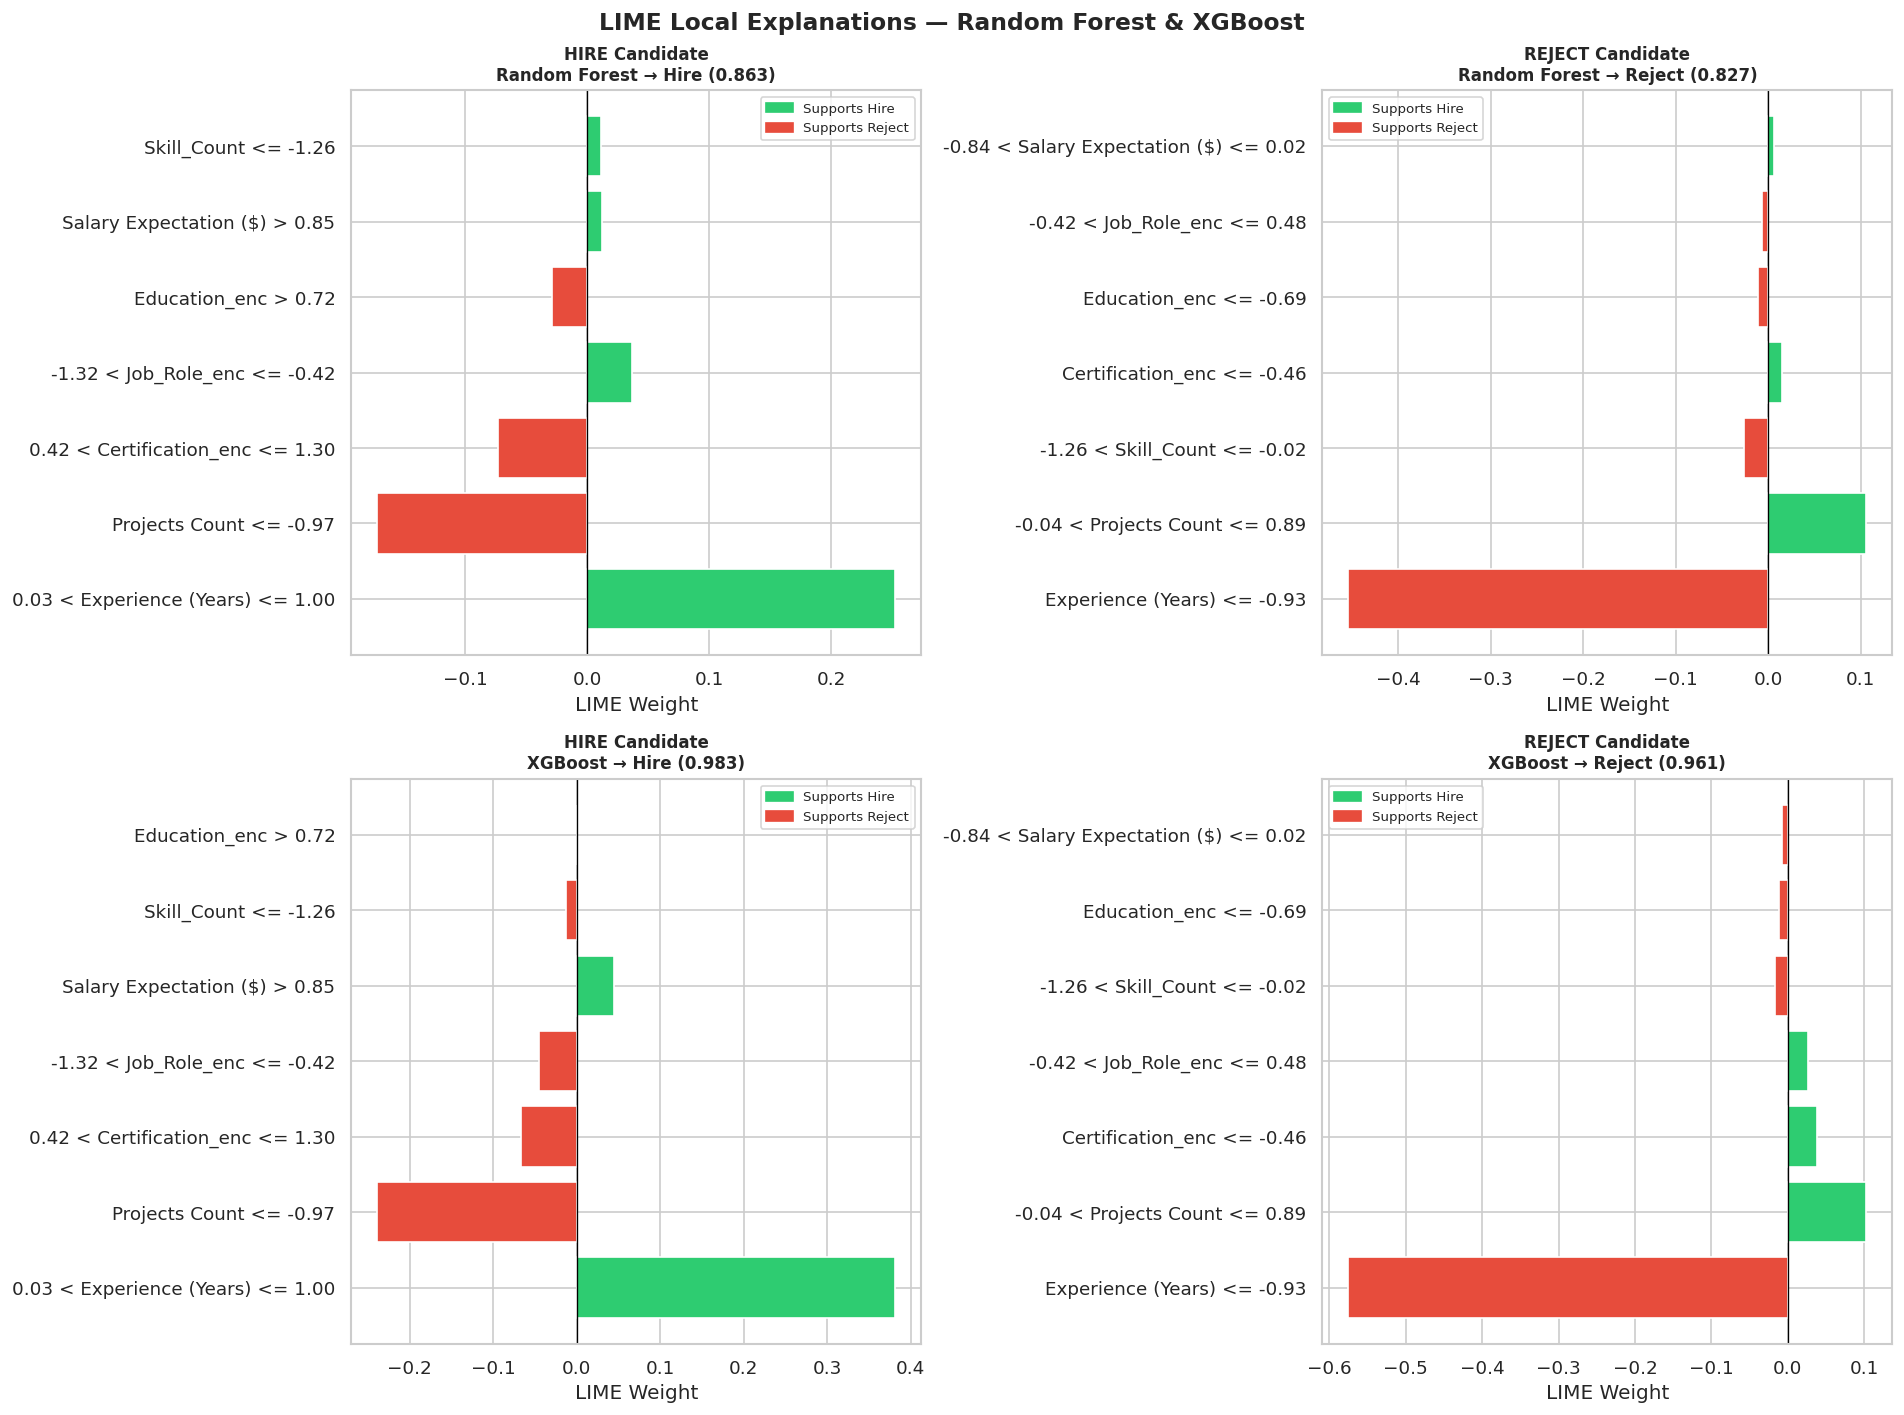

In [82]:
# LIME Visualisation
def plot_lime_explanation(exp, title, model_name, pred_label, pred_prob, ax_bar):
    """Plot LIME feature contributions as a horizontal bar chart."""
    feat_vals = exp.as_list()
    feats     = [f[0] for f in feat_vals]
    weights   = [f[1] for f in feat_vals]
    colors    = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]

    ax_bar.barh(feats, weights, color=colors)
    ax_bar.axvline(0, color='black', linewidth=0.8)
    ax_bar.set_title(f'{title}\n{model_name} ﷿﷿﷿ {pred_label} ({pred_prob:.3f})',
                     fontsize=10, fontweight='bold')
    ax_bar.set_xlabel('LIME Weight')
    green = mpatches.Patch(color='#2ecc71', label='Supports Hire')
    red   = mpatches.Patch(color='#e74c3c', label='Supports Reject')
    ax_bar.legend(handles=[green, red], fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LIME Local Explanations ﷿﷿﷿ Random Forest & XGBoost', fontsize=14, fontweight='bold')

# RF on Hire
plot_lime_explanation(
    lime_exp_hire_rf, 'HIRE Candidate', 'Random Forest',
    'Hire', rf_model.predict_proba([hire_instance])[0][1], axes[0,0]
)

# LIME Local Explanation: Rejected Candidate
reject_instance = X_test[reject_idx]
lime_exp_reject_rf = lime_explainer.explain_instance(
    data_row       = reject_instance,
    predict_fn     = rf_model.predict_proba,
    num_features   = 8,
    num_samples    = 1000
)

# RF on Reject
plot_lime_explanation(
    lime_exp_reject_rf, 'REJECT Candidate', 'Random Forest',
    'Reject', rf_model.predict_proba([reject_instance])[0][0], axes[0,1]
)

# XGBoost on Hire
lime_exp_hire_xgb = lime_explainer.explain_instance(
    hire_instance, xgb_model.predict_proba, num_features=8, num_samples=1000
)
plot_lime_explanation(
    lime_exp_hire_xgb, 'HIRE Candidate', 'XGBoost',
    'Hire', xgb_model.predict_proba([hire_instance])[0][1], axes[1,0]
)

# XGBoost on Reject
lime_exp_reject_xgb = lime_explainer.explain_instance(
    reject_instance, xgb_model.predict_proba, num_features=8, num_samples=1000
)
plot_lime_explanation(
    lime_exp_reject_xgb, 'REJECT Candidate', 'XGBoost',
    'Reject', xgb_model.predict_proba([reject_instance])[0][0], axes[1,1]
)

plt.tight_layout()
plt.savefig('lime_explanations.png', bbox_inches='tight')
plt.show()

## SHAP vs LIME Comparison

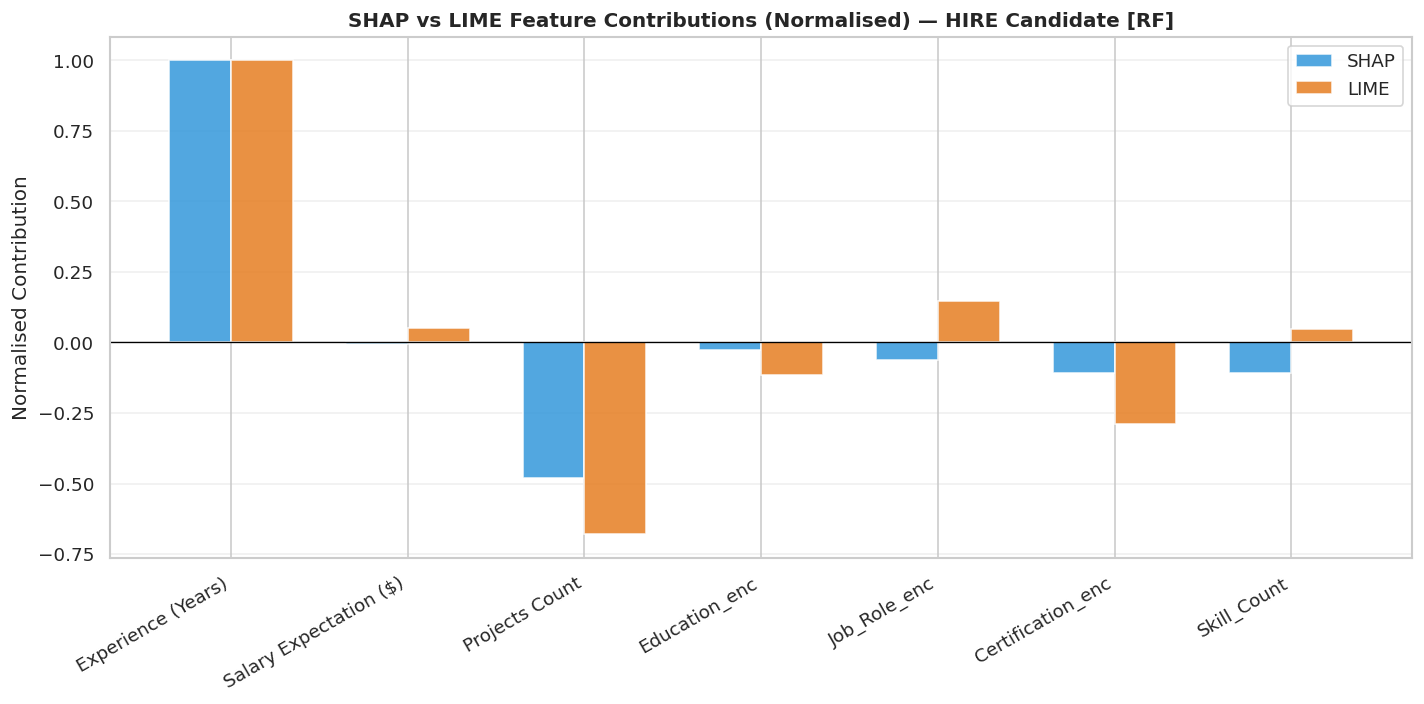

 SHAP vs LIME comparison saved
Pearson  r : 0.9532
Spearman r : 0.7500
 High agreement between SHAP and LIME.


In [83]:
# SHAP vs LIME: Side-by-side feature importance (HIRE candidate)
from scipy.stats import pearsonr, spearmanr

shap_weights_d = dict(zip(FEATURES, shap_vals_hire[hire_idx]))
lime_raw_d     = dict(lime_exp_hire_rf.as_list())
lime_clean     = {}
for feat_str, val in lime_raw_d.items():
    for feat in FEATURES:
        if feat in feat_str:
            lime_clean[feat] = lime_clean.get(feat, 0) + val
            break

common_feats = [f for f in FEATURES if f in lime_clean]
sh_arr = np.array([shap_weights_d.get(f, 0) for f in common_feats])
li_arr = np.array([lime_clean.get(f, 0)     for f in common_feats])

# Normalise to [-1, 1]
sh_n = sh_arr / (np.abs(sh_arr).max() + 1e-9)
li_n = li_arr / (np.abs(li_arr).max() + 1e-9)

x_pos = np.arange(len(common_feats)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_pos - w/2, sh_n, w, label='SHAP', color='#3498db', alpha=0.85)
ax.bar(x_pos + w/2, li_n, w, label='LIME', color='#e67e22', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(common_feats, rotation=30, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('SHAP vs LIME Feature Contributions (Normalised) ﷿﷿﷿ HIRE Candidate [RF]',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Normalised Contribution'); ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_vs_lime_comparison.png', bbox_inches='tight')
plt.show()
print(' SHAP vs LIME comparison saved')

if len(common_feats) >= 2:
    pearson_r, _ = pearsonr(sh_n, li_n); spearman_r, _ = spearmanr(sh_n, li_n)
    print(f'Pearson  r : {pearson_r:.4f}')
    print(f'Spearman r : {spearman_r:.4f}')
    if pearson_r > 0.7: print(' High agreement between SHAP and LIME.')
    elif pearson_r > 0.4: print('﷿﷿﷿ Moderate agreement.')
    else: print('﷿﷿﷿ Low agreement ﷿﷿﷿ methods emphasise different features.')

## Final Summary Dashboard


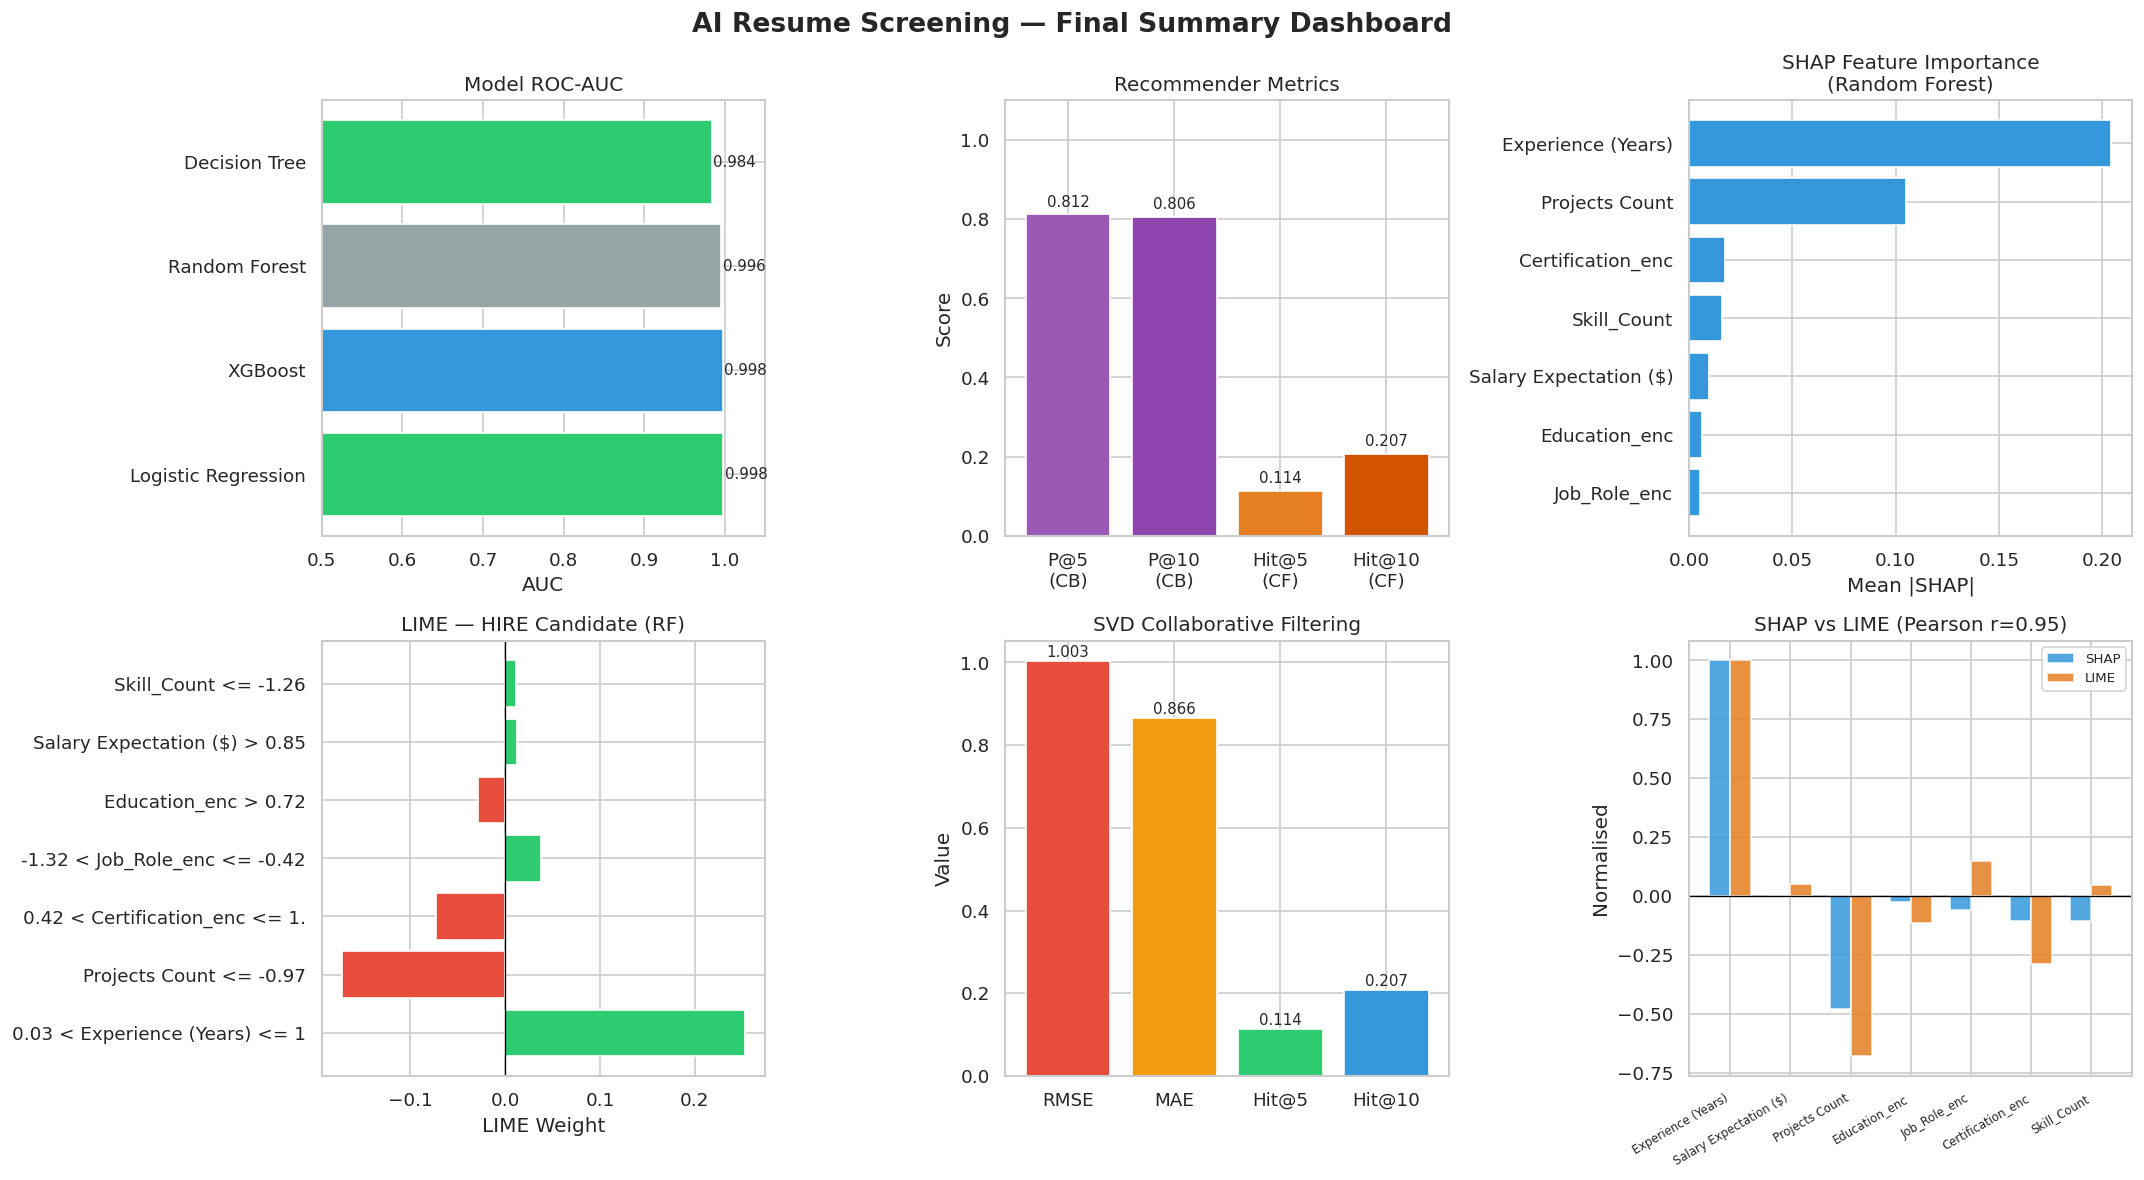

In [84]:
# Summary dashboard
fig = plt.figure(figsize=(18, 10))
fig.suptitle('AI Resume Screening ﷿﷿﷿ Final Summary Dashboard',
             fontsize=16, fontweight='bold')

# Model AUC bar
ax1 = fig.add_subplot(2, 3, 1)
mnames = results_df['Model'].tolist(); aucs = results_df['ROC-AUC'].tolist()
ax1.barh(mnames, aucs, color=['#2ecc71','#3498db','#95a5a6'])
ax1.set_xlim(0.5, 1.05); ax1.set_title('Model ROC-AUC'); ax1.set_xlabel('AUC')
for i, v in enumerate(aucs): ax1.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)

# Recommender metrics
ax2 = fig.add_subplot(2, 3, 2)
ax2.bar(['P@5\n(CB)','P@10\n(CB)','Hit@5\n(CF)','Hit@10\n(CF)'],
        [p_at_5, p_at_10, hr_5, hr_10],
        color=['#9b59b6','#8e44ad','#e67e22','#d35400'])
ax2.set_ylim(0, 1.1); ax2.set_title('Recommender Metrics'); ax2.set_ylabel('Score')
for i, v in enumerate([p_at_5,p_at_10,hr_5,hr_10]):
    ax2.text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=9)

# SHAP global importance
ax3 = fig.add_subplot(2, 3, 3)
mean_shap = np.abs(shap_vals_hire).mean(axis=0)
sidx = np.argsort(mean_shap)
ax3.barh([FEATURES[i] for i in sidx], mean_shap[sidx], color='#3498db')
ax3.set_title('SHAP Feature Importance\n(Random Forest)'); ax3.set_xlabel('Mean |SHAP|')

# LIME hire explanation
ax4 = fig.add_subplot(2, 3, 4)
l_feats   = [f[0][:30] for f in lime_exp_hire_rf.as_list()]
l_weights = [f[1]       for f in lime_exp_hire_rf.as_list()]
ax4.barh(l_feats, l_weights, color=['#2ecc71' if w>0 else '#e74c3c' for w in l_weights])
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title('LIME ﷿﷿﷿ HIRE Candidate (RF)'); ax4.set_xlabel('LIME Weight')

# SVD CF metrics
ax5 = fig.add_subplot(2, 3, 5)
ax5.bar(['RMSE','MAE','Hit@5','Hit@10'], [rmse_val, mae_val, hr_5, hr_10],
        color=['#e74c3c','#f39c12','#2ecc71','#3498db'])
ax5.set_title('SVD Collaborative Filtering'); ax5.set_ylabel('Value')
for i,v in enumerate([rmse_val,mae_val,hr_5,hr_10]):
    ax5.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

# 6. SHAP vs LIME
ax6 = fig.add_subplot(2, 3, 6)
ax6.bar(x_pos-w/2, sh_n, w, label='SHAP', color='#3498db', alpha=0.85)
ax6.bar(x_pos+w/2, li_n, w, label='LIME', color='#e67e22', alpha=0.85)
ax6.set_xticks(x_pos); ax6.set_xticklabels(common_feats, rotation=30, ha='right', fontsize=7)
ax6.axhline(0, color='black', linewidth=0.8); ax6.legend(fontsize=8)
ax6.set_title(f'SHAP vs LIME (Pearson r={pearson_r:.2f})'); ax6.set_ylabel('Normalised')

plt.tight_layout()
plt.savefig('final_dashboard.png', bbox_inches='tight')
plt.show()

## Bias Analysis

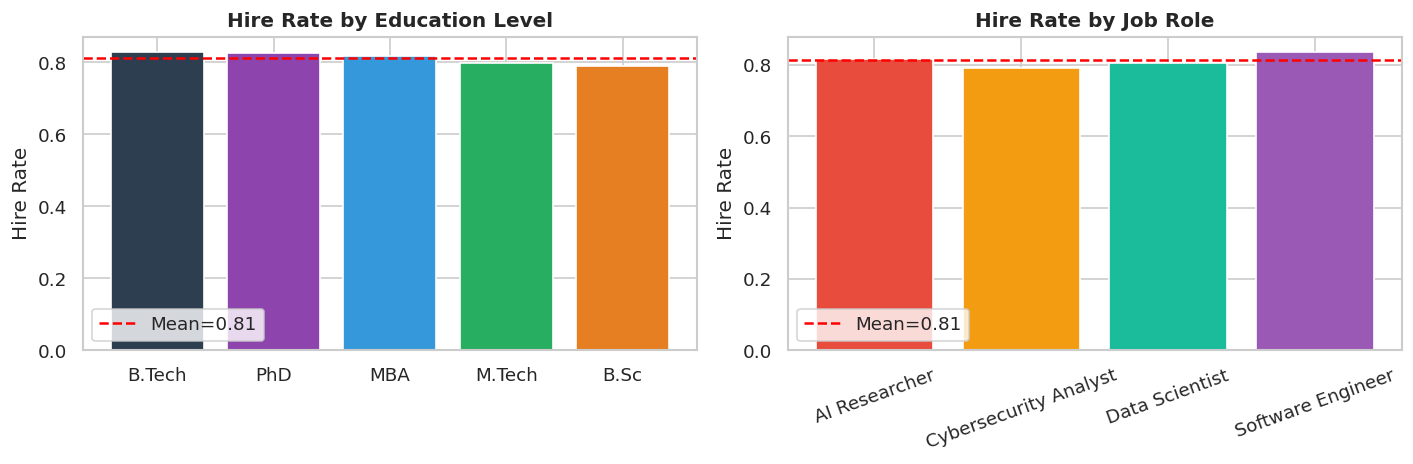


 Hire rate is relatively even across education levels and job roles.
   The key ethical concern is the OPAQUE AI SCORE ﷿﷿﷿ candidates are rejected
   not by human judgment but by an unexplained numeric threshold.


In [85]:
# Is there a systematic bias in hiring by Education level?
hire_by_edu = df.groupby('Education')['Recruiter Decision'].apply(
    lambda x: (x == 'Hire').mean()).reset_index()
hire_by_edu.columns = ['Education', 'Hire Rate']
hire_by_edu = hire_by_edu.sort_values('Hire Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(hire_by_edu['Education'], hire_by_edu['Hire Rate'],
            color=['#2c3e50','#8e44ad','#3498db','#27ae60','#e67e22'], edgecolor='white')
axes[0].axhline(y=hire_by_edu['Hire Rate'].mean(), color='red',
                linestyle='--', label=f"Mean={hire_by_edu['Hire Rate'].mean():.2f}")
axes[0].set_title('Hire Rate by Education Level', fontweight='bold')
axes[0].set_ylabel('Hire Rate')
axes[0].legend()

# Hire rate by job role
hire_by_role = df.groupby('Job Role')['Recruiter Decision'].apply(
    lambda x: (x == 'Hire').mean()).reset_index()
hire_by_role.columns = ['Job Role', 'Hire Rate']
axes[1].bar(hire_by_role['Job Role'], hire_by_role['Hire Rate'],
            color=['#e74c3c','#f39c12','#1abc9c','#9b59b6'], edgecolor='white')
axes[1].axhline(y=hire_by_role['Hire Rate'].mean(), color='red',
                linestyle='--', label=f"Mean={hire_by_role['Hire Rate'].mean():.2f}")
axes[1].set_title('Hire Rate by Job Role', fontweight='bold')
axes[1].set_ylabel('Hire Rate')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
plt.tight_layout(); plt.show()

print("\n Hire rate is relatively even across education levels and job roles.")
print("   The key ethical concern is the OPAQUE AI SCORE ﷿﷿﷿ candidates are rejected")
print("   not by human judgment but by an unexplained numeric threshold.")

## SHAP vs LIME comparison table

In [86]:
comparison = pd.DataFrame({
    'Property'             : ['Scope','Explanation type','Theoretical basis',
                               'Model dependency','Consistency','Speed',
                               'Global explanations','Local explanations',
                               'Best used for'],
    'SHAP' : ['Local + Global','Additive attribution','Shapley values (game theory)',
               'TreeExplainer (trees); KernelSHAP (any)','Theoretically consistent',
               'Fast with TreeExplainer','Yes (mean |SHAP|)','Yes (waterfall/force)',
               'Tree models; regulatory audit'],
    'LIME' : ['Local only','Surrogate linear model','Local linear approximation',
               'Fully model-agnostic','Varies with random sampling',
               'Moderate (depends on num_samples)','No (requires aggregation)','Yes (bar chart)',
               'Any black-box; candidate-level explanation']
})
display(comparison)

,Property,SHAP,LIME
0,Scope,Local + Global,Local only
1,Explanation type,Additive attribution,Surrogate linear model
2,Theoretical basis,Shapley values (game theory),Local linear approximation
3,Model dependency,TreeExplainer (trees); KernelSHAP (any),Fully model-agnostic
4,Consistency,Theoretically consistent,Varies with random sampling
5,Speed,Fast with TreeExplainer,Moderate (depends on num_samples)
6,Global explanations,Yes (mean |SHAP|),No (requires aggregation)
7,Local explanations,Yes (waterfall/force),Yes (bar chart)
8,Best used for,Tree models; regulatory audit,Any black-box; candidate-level explanation


##Deployment

In [87]:
import subprocess, sys
_deploy_packages = [
    ("flask",      "flask"),
    ("pyngrok",    "pyngrok"),
    ("flask-cors", "flask_cors"),
]

print("Installing deployment dependencies.")
for pip_name, import_name in _deploy_packages:
    try:
        __import__(import_name)
        print(f" {pip_name} already installed")
    except ImportError:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pip_name, "-q"],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f" {pip_name} installed")
        else:
            print(f" {pip_name} error: {result.stderr[:120]}")

print("\n All deployment dependencies ready")

Installing deployment dependencies.
 flask already installed
 pyngrok already installed
 flask-cors already installed

 All deployment dependencies ready


In [88]:
import numpy as np
# Detect Trained Model
_MODEL_CANDIDATES = [
    "best_model", "model", "clf", "classifier", "pipeline",
    "best_clf", "final_model", "trained_model", "rf_model",
    "xgb_model", "gb_model", "lr_model", "svm_model", "dt_model",
    "knn_model", "estimator", "best_estimator",
]

flask_model      = None
flask_model_type = "Unknown"

for _var in _MODEL_CANDIDATES:
    _obj = globals().get(_var)
    if _obj is not None and hasattr(_obj, "predict"):
        flask_model      = _obj
        flask_model_type = type(_obj).__name__
        print(f" Model found   ﷿﷿﷿ '{_var}'  ({flask_model_type})")
        break

if flask_model is None:
    print(" No trained model auto-detected in globals().")
    print("   ﷿﷿﷿  Set  flask_model = <your_model>  manually and re-run this cell.")

# Detect Feature Names
_FEAT_CANDIDATES = [
    "feature_names", "FEATURES", "features", "feature_cols", "feature_columns",
    "selected_features", "X_train", "X_test", "X", "features_list",
]

flask_feature_names = None

for _var in _FEAT_CANDIDATES:
    _obj = globals().get(_var)
    if _obj is None:
        continue
    if hasattr(_obj, "columns"):
        flask_feature_names = list(_obj.columns)
        print(f" Features found ﷿﷿﷿ '{_var}'.columns  ({len(flask_feature_names)} features)")
        break
    if isinstance(_obj, (list, tuple, np.ndarray)) and len(_obj) > 0:
        if isinstance(_obj[0], str):
            flask_feature_names = list(_obj)
            print(f" Features found ﷿﷿﷿ '{_var}'  ({len(flask_feature_names)} features)")
            break

if flask_feature_names is None and flask_model is not None:
    try:
        if hasattr(flask_model, "feature_names_in_"):
            flask_feature_names = list(flask_model.feature_names_in_)
            print(f" Features found ﷿﷿﷿ model.feature_names_in_  ({len(flask_feature_names)} features)")
        elif hasattr(flask_model, "named_steps"):
            for _step in flask_model.named_steps.values():
                if hasattr(_step, "feature_names_in_"):
                    flask_feature_names = list(_step.feature_names_in_)
                    print(f" Features found ﷿﷿﷿ pipeline step.feature_names_in_  ({len(flask_feature_names)} features)")
                    break
    except Exception:
        pass

# Default: canonical AI Resume Screening dataset columns
if flask_feature_names is None:
    flask_feature_names = [
        "Age", "Gender", "EducationLevel", "ExperienceYears",
        "PreviousCompanies", "DistanceFromCompany",
        "InterviewScore", "SkillScore", "PersonalityScore",
        "RecruitmentStrategy",
    ]
    print(f"﷿﷿﷿  Feature names not found ﷿﷿﷿ using default resume-screening columns.")

# Detect Class Labels
flask_classes = ["Not Selected", "Selected"]

for _var in ["class_names", "classes", "target_names", "label_names"]:
    _obj = globals().get(_var)
    if _obj is not None and isinstance(_obj, (list, tuple, np.ndarray)):
        flask_classes = [str(c) for c in _obj]
        print(f" Classes found  ﷿﷿﷿ '{_var}'  {flask_classes}")
        break

if flask_model is not None and hasattr(flask_model, "classes_"):
    flask_classes = [str(c) for c in flask_model.classes_]
    print(f" Classes found  ﷿﷿﷿ model.classes_  {flask_classes}")

# Detect Scaler / Label Encoder
flask_scaler = None
for _var in ["scaler", "sc", "std_scaler", "min_max_scaler", "normalizer"]:
    _obj = globals().get(_var)
    if _obj is not None and hasattr(_obj, "transform"):
        flask_scaler = _obj
        print(f" Scaler found   ﷿﷿﷿ '{_var}'  ({type(_obj).__name__})")
        break

flask_le = None
for _var in ["le", "label_encoder", "le_target", "target_encoder"]:
    _obj = globals().get(_var)
    if _obj is not None and hasattr(_obj, "inverse_transform"):
        flask_le = _obj
        print(f" LabelEncoder   ﷿﷿﷿ '{_var}'  ({type(_obj).__name__})")
        break

# Summary
print()
print("=" * 58)
print("   DEPLOYMENT CONFIGURATION SUMMARY")
print("=" * 58)
print(f"  Model      : {flask_model_type if flask_model else ' NOT FOUND'}")
print(f"  # Features : {len(flask_feature_names)}")
print(f"  Features   : {flask_feature_names}")
print(f"  Classes    : {flask_classes}")
print(f"  Scaler     : {' ' + type(flask_scaler).__name__ if flask_scaler else 'Not detected'}")
print(f"  LabelEnc   : {' Found' if flask_le else 'Not detected'}")
print("=" * 58)

 Model found   ﷿﷿﷿ 'rf_model'  (RandomForestClassifier)
 Features found ﷿﷿﷿ 'FEATURES'  (7 features)
 Classes found  ﷿﷿﷿ model.classes_  ['0', '1']
 Scaler found   ﷿﷿﷿ 'scaler'  (StandardScaler)

   DEPLOYMENT CONFIGURATION SUMMARY
  Model      : RandomForestClassifier
  # Features : 7
  Features   : ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'Education_enc', 'Job_Role_enc', 'Certification_enc', 'Skill_Count']
  Classes    : ['0', '1']
  Scaler     :  StandardScaler
  LabelEnc   : Not detected


In [89]:
from flask import Flask, request, jsonify, render_template_string
from flask_cors import CORS
from datetime import datetime
import numpy as np
import json

app = Flask(__name__)
CORS(app)

def _build_feature_vector(input_dict):
    """Construct a (1, n_features) numpy array from the POST body."""
    return np.array([[float(input_dict.get(f, 0)) for f in flask_feature_names]])

def _apply_scaler(X):
    if flask_scaler is not None:
        try:
            return flask_scaler.transform(X)
        except Exception as e:
            print(f"  Scaler warning: {e}")
    return X

def _decode_label(pred_int):
    if flask_le is not None:
        try:
            return str(flask_le.inverse_transform([pred_int])[0])
        except Exception:
            pass
    if pred_int < len(flask_classes):
        return str(flask_classes[pred_int])
    return str(pred_int)

def _compute_explanation(X, pred_int):
    """Try SHAP ﷿﷿﷿ coef / feature_importances ﷿﷿﷿ empty dict."""
    feat_names = flask_feature_names
    explanation = {}

    try:
        import shap

        base_model = flask_model
        X_for_shap = X

        # Unwrap sklearn Pipeline
        if hasattr(flask_model, "named_steps"):
            steps = list(flask_model.named_steps.items())
            for _, step in steps[:-1]:
                if hasattr(step, "transform"):
                    X_for_shap = step.transform(X_for_shap)
            base_model = steps[-1][1]

        try:
            explainer  = shap.TreeExplainer(base_model)
            shap_vals  = explainer.shap_values(X_for_shap)

            if isinstance(shap_vals, list):
                sv = shap_vals[pred_int][0]
            elif shap_vals.ndim == 3:
                sv = shap_vals[0, :, pred_int]
            else:
                sv = shap_vals[0]

            explanation = {n: float(v) for n, v in zip(feat_names, sv)}

        except Exception:
            # Linear / KernelExplainer fallback (slower but universal)
            bg = np.zeros((1, X_for_shap.shape[1]))
            explainer = shap.KernelExplainer(
                base_model.predict_proba
                if hasattr(base_model, "predict_proba")
                else base_model.predict,
                bg,
            )
            sv = explainer.shap_values(X_for_shap, nsamples=100)
            if isinstance(sv, list):
                sv = sv[pred_int]
            explanation = {n: float(v) for n, v in zip(feat_names, sv[0])}

    except ImportError:
        pass
    except Exception as e:
        print(f"  SHAP error: {e}")

    # Feature importances / coefficients (fallback)
    if not explanation:
        try:
            base = flask_model
            if hasattr(flask_model, "named_steps"):
                base = list(flask_model.named_steps.values())[-1]
            if hasattr(base, "feature_importances_"):
                vals = base.feature_importances_
            elif hasattr(base, "coef_"):
                coef = base.coef_
                vals = coef[pred_int] if coef.ndim > 1 and pred_int < coef.shape[0] else coef.ravel()
            else:
                vals = None
            if vals is not None:
                explanation = {n: float(v) for n, v in zip(feat_names, vals)}
        except Exception:
            pass

    return explanation

def run_prediction(input_dict):
    """Full prediction pipeline ﷿﷿﷿ returns a dict ready for JSON serialisation."""
    if flask_model is None:
        raise RuntimeError(
            "No model found. Set `flask_model = <your_trained_model>` "
            "and re-run Cell 2."
        )

    X         = _build_feature_vector(input_dict)
    X_scaled  = _apply_scaler(X)
    pred_raw  = flask_model.predict(X_scaled)[0]
    pred_int  = int(pred_raw)
    pred_label = _decode_label(pred_int)

    prob_list  = None
    confidence = None
    if hasattr(flask_model, "predict_proba"):
        probs      = flask_model.predict_proba(X_scaled)[0]
        prob_list  = [round(float(p), 4) for p in probs]
        confidence = round(float(max(probs)), 4)

    explanation = _compute_explanation(X_scaled, pred_int)

    return {
        "prediction":       pred_int,
        "prediction_label": pred_label,
        "probability":      prob_list,
        "confidence":       confidence,
        "explanation":      explanation,
        "timestamp":        datetime.now().strftime("%d %b %Y  %H:%M:%S"),
    }

# FORM GENERATOR
_FEATURE_META = {
    "experience(years)": dict(
        label="Experience (Years)", icon="fa-briefcase", group="Professional Background",
        type="range", min=0, max=20, step=1, default=5,
        tooltip="Total years of relevant work experience (0 ﷿﷿﷿ 20)",
    ),
    "salaryexpectation($)": dict(
        label="Salary Expectation ($)", icon="fa-dollar-sign", group="Financial",
        type="number", min=20000, max=300000, step=1000, placeholder="e.g. 75000",
        tooltip="Expected annual salary in USD",
    ),
    "projectscount": dict(
        label="Projects Count", icon="fa-folder-open", group="Professional Background",
        type="number", min=0, max=50, step=1, placeholder="e.g. 5",
        tooltip="Total number of relevant projects completed",
    ),
    "educationenc": dict(
        label="Education Level", icon="fa-graduation-cap", group="Academic Background",
        type="select",
        options=[(0, "Certificate / Diploma"), (1, "Bachelor's Degree"), (2, "Master's Degree"), (3, "PhD")],
        tooltip="Highest education level (label-encoded: 0=Cert, 1=Bachelor's, 2=Master's, 3=PhD)",
    ),
    "jobroleenc": dict(
        label="Job Role (Encoded)", icon="fa-id-badge", group="Professional Background",
        type="number", min=0, max=30, step=1, placeholder="e.g. 3",
        tooltip="Job role category as encoded by LabelEncoder (integer)",
    ),
    "certificationenc": dict(
        label="Certifications (Encoded)", icon="fa-certificate", group="Qualifications",
        type="number", min=0, max=30, step=1, placeholder="e.g. 1",
        tooltip="Certifications level encoded by LabelEncoder (0 = None)",
    ),
    "skillcount": dict(
        label="Skill Count", icon="fa-star", group="Professional Background",
        type="range", min=1, max=20, step=1, default=5,
        tooltip="Number of distinct technical skills listed in the profile",
    ),
    # Legacy / alternative UI field names (kept for compatibility)
    "age": dict(
        label="Age", icon="fa-user", group="Personal Information",
        type="number", min=18, max=65, step=1, placeholder="e.g. 28",
        tooltip="Candidate age in years (18 ﷿﷿﷿ 65)",
    ),
    "gender": dict(
        label="Gender", icon="fa-venus-mars", group="Personal Information",
        type="select", options=[(0, "Female"), (1, "Male")],
        tooltip="Candidate gender",
    ),
    "educationlevel": dict(
        label="Education Level", icon="fa-graduation-cap", group="Academic Background",
        type="select",
        options=[(1, "Bachelor's Degree"), (2, "Master's Degree"), (3, "PhD"), (4, "Other")],
        tooltip="Highest level of education attained",
    ),
    "experienceyears": dict(
        label="Experience (Years)", icon="fa-briefcase", group="Professional Background",
        type="range", min=0, max=20, step=1, default=5,
        tooltip="Total years of relevant work experience",
    ),
    "previouscompanies": dict(
        label="Previous Companies", icon="fa-building", group="Professional Background",
        type="range", min=0, max=10, step=1, default=2,
        tooltip="Number of previous employers",
    ),
    "distancefromcompany": dict(
        label="Distance from Company (km)", icon="fa-location-dot", group="Logistics",
        type="number", min=0, max=200, step=1, placeholder="e.g. 15",
        tooltip="Distance from home to office in km",
    ),
    "interviewscore": dict(
        label="Interview Score", icon="fa-comments", group="Assessment Scores",
        type="range", min=0, max=100, step=1, default=70,
        tooltip="Interview performance score (0 ﷿﷿﷿ 100)",
    ),
    "skillscore": dict(
        label="Skill Score", icon="fa-star", group="Assessment Scores",
        type="range", min=0, max=100, step=1, default=65,
        tooltip="Technical skill assessment score (0 ﷿﷿﷿ 100)",
    ),
    "personalityscore": dict(
        label="Personality Score", icon="fa-brain", group="Assessment Scores",
        type="range", min=0, max=100, step=1, default=60,
        tooltip="Soft-skills and personality score (0 ﷿﷿﷿ 100)",
    ),
    "recruitmentstrategy": dict(
        label="Recruitment Strategy", icon="fa-chess", group="Recruitment",
        type="select", options=[(1, "Aggressive"), (2, "Moderate"), (3, "Conservative")],
        tooltip="Recruitment method used to source this candidate",
    ),
}

def _meta(feature_name):
    key = feature_name.lower().replace("_", "").replace(" ", "")
    if key in _FEATURE_META:
        return dict(_FEATURE_META[key], name=feature_name)
    n = feature_name.lower()
    if any(t in n for t in ("score", "rating", "grade")):
        return dict(label=feature_name.replace("_"," ").title(), icon="fa-chart-line",
                    group="Scores", type="range", min=0, max=100, step=1, default=50,
                    tooltip=f"{feature_name} (0﷿﷿﷿100)", name=feature_name)
    if any(t in n for t in ("year", "age", "experience", "count", "num", "prev")):
        return dict(label=feature_name.replace("_"," ").title(), icon="fa-calendar",
                    group="Background", type="number", min=0, max=50, step=1,
                    placeholder="Enter value", tooltip=feature_name, name=feature_name)
    if any(t in n for t in ("gender", "sex")):
        return dict(label="Gender", icon="fa-venus-mars", group="Personal",
                    type="select", options=[(0,"Female"),(1,"Male")],
                    tooltip="Gender", name=feature_name)
    if any(t in n for t in ("education","degree","level")):
        return dict(label="Education Level", icon="fa-graduation-cap", group="Academic",
                    type="select",
                    options=[(1,"Bachelor's"),(2,"Master's"),(3,"PhD"),(4,"Other")],
                    tooltip="Education level", name=feature_name)
    if any(t in n for t in ("strategy","type","category","mode")):
        return dict(label=feature_name.replace("_"," ").title(), icon="fa-list",
                    group="Category", type="select",
                    options=[(1,"Option 1"),(2,"Option 2"),(3,"Option 3")],
                    tooltip=feature_name, name=feature_name)
    return dict(label=feature_name.replace("_"," ").title(), icon="fa-hashtag",
                group="Other", type="number", min=0, max=100, step=1,
                placeholder="Enter value", tooltip=feature_name, name=feature_name)

def generate_form_html():
    groups = {}
    for feat in flask_feature_names:
        m = _meta(feat)
        groups.setdefault(m["group"], []).append(m)

    html_parts = []
    for grp, metas in groups.items():
        html_parts.append(
            f'<div class="section-label">'
            f'<i class="fas fa-layer-group me-2"></i>{grp}'
            f'</div>'
        )
        html_parts.append('<div class="row g-3 mb-4">')
        for m in metas:
            col = '<div class="col-md-6 col-lg-4">'
            lbl = (
                f'<label class="form-label" '
                f'data-bs-toggle="tooltip" data-bs-placement="top" title="{m.get("tooltip","")}">'
                f'<i class="fas {m.get("icon","fa-hashtag")} me-2 field-icon"></i>'
                f'{m["label"]}'
                f'</label>'
            )
            if m["type"] == "select":
                opts = "".join(
                    f'<option value="{v}">{lbl2}</option>'
                    for v, lbl2 in m.get("options", [])
                )
                inp = (
                    f'<select name="{m["name"]}" class="form-select" required>'
                    f'<option value="" disabled selected>Select﷿﷿﷿</option>'
                    f'{opts}'
                    f'</select>'
                )
            elif m["type"] == "range":
                dflt = m.get("default", m.get("min", 0))
                rid  = f'rv_{m["name"]}'
                inp = (
                    f'<div class="range-wrap">'
                    f'<div class="range-header">'
                    f'<span class="range-bounds">{m.get("min",0)} ﷿﷿﷿ {m.get("max",100)}</span>'
                    f'<span class="range-bubble" id="{rid}">{dflt}</span>'
                    f'</div>'
                    f'<input type="range" class="form-range" name="{m["name"]}" '
                    f'min="{m.get("min",0)}" max="{m.get("max",100)}" '
                    f'step="{m.get("step",1)}" value="{dflt}" required '
                    f"oninput=\"document.getElementById('{rid}').textContent=this.value\">"
                    f'</div>'
                )
            else:
                attrs = ""
                for attr in ("min", "max", "step"):
                    if attr in m:
                        attrs += f' {attr}="{m[attr]}"'
                inp = (
                    f'<input type="number" class="form-control" name="{m["name"]}" '
                    f'placeholder="{m.get("placeholder","")}"'
                    f'{attrs} required>'
                )
            fb  = '<div class="invalid-feedback">Required field.</div>'
            html_parts.append(f'{col}{lbl}{inp}{fb}</div>')
        html_parts.append('</div>')

    return "\n".join(html_parts)

# HTML TEMPLATE
_HTML = r"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>ResumeAI XAI ﷿﷿﷿ Candidate Screening</title>
  <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.2/dist/css/bootstrap.min.css" rel="stylesheet"/>
  <link href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.0/css/all.min.css" rel="stylesheet"/>
  <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800;900&display=swap" rel="stylesheet"/>
  <style>
    /* ﷿﷿﷿﷿﷿﷿ TOKENS ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    :root {
      --bg:        #060918;
      --bg2:       #0c1130;
      --card:      rgba(255,255,255,.045);
      --border:    rgba(255,255,255,.08);
      --blue:      #4f6ef7;
      --purple:    #8b5cf6;
      --green:     #10b981;
      --red:       #ef4444;
      --amber:     #f59e0b;
      --txt:       #f1f5f9;
      --txt2:      #94a3b8;
      --glow:      0 0 45px rgba(79,110,247,.18);
      --radius:    18px;
    }
    *,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
    html{scroll-behavior:smooth}
    body{
      background:var(--bg);
      font-family:'Inter',sans-serif;
      color:var(--txt);
      min-height:100vh;
      overflow-x:hidden;
    }
    /* Ambient blobs */
    body::before{
      content:'';position:fixed;inset:0;pointer-events:none;z-index:0;
      background:
        radial-gradient(ellipse 60% 50% at 15% 15%,rgba(79,110,247,.13) 0%,transparent 70%),
        radial-gradient(ellipse 50% 45% at 85% 80%,rgba(139,92,246,.10) 0%,transparent 70%);
    }

    /* ﷿﷿﷿﷿﷿﷿ NAVBAR ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    .site-nav{
      position:sticky;top:0;z-index:900;
      background:rgba(6,9,24,.88);
      backdrop-filter:blur(22px);
      border-bottom:1px solid var(--border);
      padding:.9rem 0;
    }
    .brand{
      font-size:1.25rem;font-weight:800;
      background:linear-gradient(135deg,var(--blue),var(--purple));
      -webkit-background-clip:text;-webkit-text-fill-color:transparent;
    }
    .status-pill{
      display:inline-flex;align-items:center;gap:.4rem;
      background:rgba(255,255,255,.06);border:1px solid var(--border);
      border-radius:50px;padding:.3rem .9rem;font-size:.72rem;font-weight:600;
      color:var(--txt2);
    }
    .status-pill .dot{width:7px;height:7px;border-radius:50%;animation:blink 2s ease infinite}
    .dot-green{background:var(--green)} .dot-blue{background:var(--blue)}
    @keyframes blink{0%,100%{opacity:1}50%{opacity:.3}}

    /* ﷿﷿﷿﷿﷿﷿ HERO ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    .hero{padding:3.5rem 0 2rem;text-align:center;position:relative;z-index:1}
    .hero-title{
      font-size:clamp(1.9rem,4vw,2.9rem);font-weight:900;line-height:1.15;
      margin-bottom:.9rem;
    }
    .hero-title span{
      background:linear-gradient(135deg,var(--blue),var(--purple),#ec4899);
      -webkit-background-clip:text;-webkit-text-fill-color:transparent;
    }
    .hero-sub{
      color:var(--txt2);font-size:1.05rem;
      max-width:580px;margin:0 auto 2rem;line-height:1.7;
    }
    .pill-row{display:flex;justify-content:center;flex-wrap:wrap;gap:.65rem;margin-bottom:2.5rem}
    .hero-pill{
      background:rgba(79,110,247,.08);border:1px solid rgba(79,110,247,.25);
      border-radius:50px;padding:.35rem 1rem;font-size:.78rem;font-weight:600;
      color:var(--blue);
    }

    /* ﷿﷿﷿﷿﷿﷿ CARDS ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    .g-card{
      background:var(--card);border:1px solid var(--border);
      border-radius:var(--radius);backdrop-filter:blur(18px);
      box-shadow:var(--glow);padding:1.75rem;position:relative;z-index:1;
      overflow:hidden;
    }
    .g-card::before{
      content:'';position:absolute;inset:0;border-radius:var(--radius);
      background:linear-gradient(135deg,rgba(255,255,255,.04) 0%,transparent 55%);
      pointer-events:none;
    }
    .c-head{
      display:flex;align-items:center;gap:.8rem;
      padding-bottom:1.1rem;margin-bottom:1.4rem;
      border-bottom:1px solid var(--border);
    }
    .c-icon{
      width:40px;height:40px;border-radius:10px;
      display:flex;align-items:center;justify-content:center;
      font-size:1rem;flex-shrink:0;
    }
    .c-title{font-size:1rem;font-weight:700;line-height:1.2}
    .c-sub{font-size:.76rem;color:var(--txt2);margin-top:.15rem}

    /* ﷿﷿﷿﷿﷿﷿ SECTION LABEL ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    .section-label{
      font-size:.68rem;text-transform:uppercase;letter-spacing:2px;
      color:var(--blue);font-weight:700;margin-bottom:.9rem;
      display:flex;align-items:center;gap:.6rem;
    }
    .section-label::after{content:'';flex:1;height:1px;background:var(--border)}

    /* ﷿﷿﷿﷿﷿﷿ FORM ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    .form-label{
      font-size:.78rem;font-weight:600;text-transform:uppercase;
      letter-spacing:.5px;color:var(--txt2);margin-bottom:.5rem;
      display:block;cursor:help;
    }
    .field-icon{color:var(--blue)!important}
    .form-control,.form-select{
      background:rgba(255,255,255,.055)!important;
      border:1px solid var(--border)!important;
      color:var(--txt)!important;border-radius:10px!important;
      padding:.72rem 1rem!important;font-size:.92rem!important;
      transition:all .2s!important;
    }
    .form-control:focus,.form-select:focus{
      background:rgba(79,110,247,.1)!important;
      border-color:var(--blue)!important;
      box-shadow:0 0 0 3px rgba(79,110,247,.18)!important;outline:none!important;
    }
    .form-control::placeholder{color:rgba(148,163,184,.45)!important}
    .form-select option{background:#0c1130;color:var(--txt)}
    .form-control.is-invalid,.form-select.is-invalid{border-color:var(--red)!important}
    .invalid-feedback{color:var(--red)!important;font-size:.75rem;margin-top:.25rem}

    /* Range */
    .range-wrap{padding:.2rem 0}
    .range-header{display:flex;justify-content:space-between;align-items:center;margin-bottom:.5rem}
    .range-bounds{font-size:.72rem;color:rgba(148,163,184,.4)}
    .range-bubble{
      background:linear-gradient(135deg,var(--blue),var(--purple));
      color:#fff;font-size:.72rem;font-weight:700;
      padding:.15rem .55rem;border-radius:20px;min-width:32px;text-align:center;
    }
    .form-range{
      -webkit-appearance:none;width:100%;height:5px;
      background:rgba(255,255,255,.1);border-radius:3px;outline:none;
    }
    .form-range::-webkit-slider-thumb{
      -webkit-appearance:none;width:18px;height:18px;border-radius:50%;
      background:linear-gradient(135deg,var(--blue),var(--purple));
      cursor:pointer;box-shadow:0 0 8px rgba(79,110,247,.5);transition:.15s;
    }
    .form-range::-webkit-slider-thumb:hover{transform:scale(1.15)}

    /* ﷿﷿﷿﷿﷿﷿ BUTTONS ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    .btn-predict{
      background:linear-gradient(135deg,var(--blue),var(--purple));
      border:none;color:#fff;font-weight:700;font-size:1rem;
      padding:.85rem 2.4rem;border-radius:50px;cursor:pointer;
      box-shadow:0 4px 22px rgba(79,110,247,.45);transition:all .25s;
    }
    .btn-predict:hover{transform:translateY(-2px);box-shadow:0 8px 32px rgba(79,110,247,.65)}
    .btn-predict:active{transform:translateY(0)}
    .btn-reset{
      background:transparent;border:1px solid var(--border);
      color:var(--txt2);font-weight:600;padding:.85rem 1.8rem;
      border-radius:50px;cursor:pointer;transition:all .25s;
    }
    .btn-reset:hover{background:rgba(255,255,255,.055);border-color:rgba(255,255,255,.2);color:var(--txt)}
    .btn-another{
      background:linear-gradient(135deg,var(--green),#059669);
      border:none;color:#fff;font-weight:700;padding:.85rem 2rem;
      border-radius:50px;cursor:pointer;
      box-shadow:0 4px 22px rgba(16,185,129,.35);transition:all .25s;
    }
    .btn-another:hover{transform:translateY(-2px);box-shadow:0 8px 28px rgba(16,185,129,.55)}

    /* ﷿﷿﷿﷿﷿﷿ LOADING OVERLAY ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    #loadingOverlay{
      position:fixed;inset:0;z-index:9999;
      background:rgba(6,9,24,.88);backdrop-filter:blur(12px);
      display:flex;flex-direction:column;align-items:center;justify-content:center;
      opacity:0;pointer-events:none;transition:opacity .3s;
    }
    #loadingOverlay.active{opacity:1;pointer-events:all}
    .spin-ring{
      width:58px;height:58px;border-radius:50%;margin-bottom:1.2rem;
      border:3px solid rgba(79,110,247,.2);border-top-color:var(--blue);
      animation:spin .75s linear infinite;
    }
    @keyframes spin{to{transform:rotate(360deg)}}
    .load-label{color:var(--txt2);font-size:.88rem;margin-bottom:.3rem}
    .load-sub{color:rgba(148,163,184,.4);font-size:.75rem}

    /* ﷿﷿﷿﷿﷿﷿ RESULTS SECTION ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    #resultsSection{display:none}
    #resultsSection.show{display:block;animation:fadeUp .5s ease}
    @keyframes fadeUp{from{opacity:0;transform:translateY(28px)}to{opacity:1;transform:translateY(0)}}

    /* Verdict */
    .verdict-badge{
      display:inline-flex;align-items:center;gap:.55rem;
      padding:.6rem 1.6rem;border-radius:50px;font-size:1.05rem;font-weight:700;
    }
    .v-selected{background:rgba(16,185,129,.14);border:1px solid rgba(16,185,129,.4);color:var(--green)}
    .v-rejected{background:rgba(239,68,68,.13);border:1px solid rgba(239,68,68,.38);color:var(--red)}
    .v-selected{animation:pulseGreen 2.2s ease infinite}
    .v-rejected{animation:pulseRed 2.2s ease infinite}
    @keyframes pulseGreen{0%,100%{box-shadow:0 0 0 0 rgba(16,185,129,.3)}50%{box-shadow:0 0 0 9px rgba(16,185,129,0)}}
    @keyframes pulseRed  {0%,100%{box-shadow:0 0 0 0 rgba(239,68,68,.3)} 50%{box-shadow:0 0 0 9px rgba(239,68,68,0) }}

    /* Gauge */
    .gauge-wrap{position:relative;width:190px;height:105px;margin:0 auto .6rem}
    #gaugeArc{transition:stroke-dashoffset 1.1s cubic-bezier(.4,0,.2,1),stroke .4s}
    .gauge-val{
      position:absolute;bottom:0;left:50%;transform:translateX(-50%);
      font-size:1.75rem;font-weight:800;transition:color .4s;
    }

    /* Probability / SHAP bars */
    .bar-row{margin-bottom:.75rem}
    .bar-meta{display:flex;justify-content:space-between;font-size:.78rem;margin-bottom:.35rem}
    .bar-meta .bname{color:var(--txt2)}
    .bar-track{height:8px;background:rgba(255,255,255,.06);border-radius:4px;overflow:hidden}
    .bar-fill{height:100%;border-radius:4px;transition:width 1.05s cubic-bezier(.4,0,.2,1)}
    .bf-green{background:linear-gradient(90deg,#10b981,#34d399)}
    .bf-red  {background:linear-gradient(90deg,#ef4444,#f87171)}
    .bf-blue {background:linear-gradient(90deg,#4f6ef7,#818cf8)}
    .bf-purple{background:linear-gradient(90deg,#8b5cf6,#a78bfa)}

    /* SHAP bar (thinner) */
    .shap-track{height:6px;background:rgba(255,255,255,.05);border-radius:3px;overflow:hidden}
    .shap-fill{height:100%;border-radius:3px;transition:width 1.2s cubic-bezier(.4,0,.2,1)}
    .shap-pos{background:linear-gradient(90deg,#10b981,#34d399)}
    .shap-neg{background:linear-gradient(90deg,#ef4444,#f87171)}

    /* Metric box */
    .metric-box{
      background:rgba(255,255,255,.03);border:1px solid var(--border);
      border-radius:12px;padding:.9rem .75rem;text-align:center;
    }
    .mval{font-size:1.55rem;font-weight:800}
    .mlbl{font-size:.7rem;color:var(--txt2);margin-top:.2rem;text-transform:uppercase;letter-spacing:.5px}

    /* Suggestion cards */
    .sug-card{
      display:flex;align-items:flex-start;gap:.75rem;
      padding:.75rem .9rem;background:rgba(255,255,255,.028);
      border-radius:11px;margin-bottom:.65rem;border-left:3px solid;
    }
    .sug-card.pos{border-color:var(--green)}
    .sug-card.neg{border-color:var(--red)}
    .sug-card.neu{border-color:var(--blue)}
    .sug-ico{flex-shrink:0;margin-top:2px;font-size:.95rem}
    .sug-title{font-size:.82rem;font-weight:700;margin-bottom:.18rem}
    .sug-detail{font-size:.76rem;color:var(--txt2);line-height:1.45}

    /* Summary */
    .sum-row{
      display:flex;justify-content:space-between;align-items:center;
      padding:.55rem 0;border-bottom:1px solid var(--border);font-size:.82rem;
    }
    .sum-row:last-child{border-bottom:none}
    .sum-key{color:var(--txt2)}
    .sum-val{font-weight:600;color:var(--txt)}

    /* Alerts */
    .err-alert{
      background:rgba(239,68,68,.1);border:1px solid rgba(239,68,68,.3);
      color:#ef4444;border-radius:12px;padding:.9rem 1.3rem;
      display:flex;align-items:center;gap:.75rem;font-size:.88rem;
    }

    /* Footer */
    footer{
      border-top:1px solid var(--border);padding:2rem 0;text-align:center;
      color:var(--txt2);font-size:.82rem;margin-top:4rem;position:relative;z-index:1;
    }
    .foot-brand{font-weight:800;background:linear-gradient(135deg,var(--blue),var(--purple));
      -webkit-background-clip:text;-webkit-text-fill-color:transparent}

    /* ﷿﷿﷿﷿﷿﷿ RESPONSIVE ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
    @media(max-width:768px){
      .pill-row{gap:.45rem}
      .g-card{padding:1.25rem}
      .btn-predict,.btn-reset,.btn-another{width:100%;margin-bottom:.65rem}
      .gauge-wrap{width:160px;height:90px}
      .gauge-val{font-size:1.4rem}
    }
  </style>
</head>
<body>

<!-- ﷿﷿﷿﷿﷿﷿ Loading ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ -->
<div id="loadingOverlay">
  <div class="spin-ring"></div>
  <p class="load-label">Analysing candidate profile﷿﷿﷿</p>
  <p class="load-sub">Running XAI explainability pipeline</p>
</div>

<!-- ﷿﷿﷿﷿﷿﷿ Navbar ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ -->
<nav class="site-nav">
  <div class="container d-flex align-items-center justify-content-between">
    <span class="brand"><i class="fas fa-brain me-2"></i>ResumeAI<span style="font-weight:300"> XAI</span></span>
    <div class="d-flex gap-2 flex-wrap">
      <span class="status-pill"><span class="dot dot-green"></span>Model Active</span>
      <span class="status-pill"><span class="dot dot-blue"></span>XAI Enabled</span>
    </div>
  </div>
</nav>

<!-- ﷿﷿﷿﷿﷿﷿ Main ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ -->
<div class="container py-3" style="position:relative;z-index:1">

  <!-- Hero -->
  <div class="hero">
    <h1 class="hero-title">AI-Powered<br><span>Resume Screening</span> with XAI</h1>
    <p class="hero-sub">
      Transparent, fair, and ethical hiring decisions powered by machine learning
      and SHAP-based explainability.
    </p>
    <div class="pill-row">
      <span class="hero-pill"><i class="fas fa-microchip me-2"></i>{{ model_type }}</span>
      <span class="hero-pill"><i class="fas fa-list-check me-2"></i>{{ n_features }} Features</span>
      <span class="hero-pill"><i class="fas fa-magnifying-glass-chart me-2"></i>SHAP Explanations</span>
      <span class="hero-pill"><i class="fas fa-shield-check me-2"></i>Ethics Aware</span>
    </div>
  </div>

  <!-- Error -->
  <div id="errBox" class="err-alert mb-4" style="display:none">
    <i class="fas fa-exclamation-circle fa-lg"></i>
    <span id="errMsg">Something went wrong.</span>
  </div>

  <!-- ﷿﷿﷿﷿﷿﷿ Input Form ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ -->
  <div id="formSection">
    <div class="g-card">
      <div class="c-head">
        <div class="c-icon" style="background:linear-gradient(135deg,var(--blue),var(--purple))">
          <i class="fas fa-user-tie text-white"></i>
        </div>
        <div>
          <div class="c-title">Candidate Profile</div>
          <div class="c-sub">Fill in all fields to generate an AI screening decision</div>
        </div>
      </div>

      <form id="screenForm" novalidate>
        <div id="formFields">{{ form_html | safe }}</div>

        <div class="d-flex flex-wrap justify-content-center gap-3 mt-4 pt-2">
          <button type="submit" class="btn-predict" id="submitBtn">
            <i class="fas fa-wand-magic-sparkles me-2"></i>Analyse Candidate
          </button>
          <button type="button" class="btn-reset" onclick="doReset()">
            <i class="fas fa-rotate-left me-2"></i>Reset Form
          </button>
        </div>
      </form>
    </div>
  </div>

  <!-- ﷿﷿﷿﷿﷿﷿ Results ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ -->
  <div id="resultsSection" class="mt-4">
    <div class="row g-4">

      <!-- Verdict + Gauge -->
      <div class="col-12">
        <div class="g-card">
          <div class="d-flex flex-column flex-md-row align-items-center justify-content-between gap-3">
            <div>
              <div style="font-size:.68rem;text-transform:uppercase;letter-spacing:2px;color:var(--txt2);margin-bottom:.65rem">
                AI SCREENING DECISION
              </div>
              <div id="verdictBadge"></div>
              <div id="predTime" style="font-size:.76rem;color:var(--txt2);margin-top:.75rem"></div>
            </div>
            <div class="text-center">
              <div class="gauge-wrap">
                <svg viewBox="0 0 200 110" style="width:100%">
                  <!-- bg track -->
                  <path d="M 20 100 A 80 80 0 0 1 180 100"
                        fill="none" stroke="rgba(255,255,255,.06)"
                        stroke-width="12" stroke-linecap="round"/>
                  <!-- fill arc -->
                  <path id="gaugeArc"
                        d="M 20 100 A 80 80 0 0 1 180 100"
                        fill="none" stroke="var(--blue)"
                        stroke-width="12" stroke-linecap="round"
                        stroke-dasharray="251.3" stroke-dashoffset="251.3"/>
                  <!-- needle -->
                  <line id="gaugeNeedle"
                        x1="100" y1="100" x2="100" y2="30"
                        stroke="rgba(255,255,255,.7)" stroke-width="2"
                        stroke-linecap="round"
                        transform="rotate(-90 100 100)"/>
                  <circle cx="100" cy="100" r="5" fill="rgba(255,255,255,.85)"/>
                  <text x="12"  y="115" fill="rgba(148,163,184,.45)" font-size="9" font-family="Inter,sans-serif">0%</text>
                  <text x="173" y="115" fill="rgba(148,163,184,.45)" font-size="9" font-family="Inter,sans-serif">100%</text>
                </svg>
                <div class="gauge-val" id="gaugeVal" style="color:var(--blue)">﷿﷿﷿</div>
              </div>
              <div style="font-size:.72rem;color:var(--txt2)">Confidence Score</div>
            </div>
          </div>
        </div>
      </div>

      <!-- Probability Distribution -->
      <div class="col-md-6">
        <div class="g-card h-100">
          <div class="c-head">
            <div class="c-icon" style="background:linear-gradient(135deg,#10b981,#059669)">
              <i class="fas fa-chart-pie text-white"></i>
            </div>
            <div>
              <div class="c-title">Probability Distribution</div>
              <div class="c-sub">Class-level prediction probabilities</div>
            </div>
          </div>
          <div id="probBars"></div>
          <div class="row g-2 mt-3" id="metricRow"></div>
        </div>
      </div>

      <!-- XAI Feature Attribution -->
      <div class="col-md-6">
        <div class="g-card h-100">
          <div class="c-head">
            <div class="c-icon" style="background:linear-gradient(135deg,#8b5cf6,#7c3aed)">
              <i class="fas fa-magnifying-glass-chart text-white"></i>
            </div>
            <div>
              <div class="c-title">XAI Feature Attribution</div>
              <div class="c-sub">SHAP-based feature impact scores</div>
            </div>
          </div>
          <div id="shapBars"></div>
          <p style="font-size:.7rem;color:rgba(148,163,184,.45);text-align:center;margin-top:.75rem">
            <i class="fas fa-circle" style="color:var(--green);font-size:.5rem"></i> Supports hiring &nbsp;
            <i class="fas fa-circle" style="color:var(--red);font-size:.5rem"></i> Flags concern
          </p>
        </div>
      </div>

      <!-- Recommendations -->
      <div class="col-md-6">
        <div class="g-card h-100">
          <div class="c-head">
            <div class="c-icon" style="background:linear-gradient(135deg,#f59e0b,#d97706)">
              <i class="fas fa-lightbulb text-white"></i>
            </div>
            <div>
              <div class="c-title">Recommended Actions</div>
              <div class="c-sub">AI-driven hiring guidance</div>
            </div>
          </div>
          <div id="sugBox"></div>
        </div>
      </div>

      <!-- Input Summary -->
      <div class="col-md-6">
        <div class="g-card h-100">
          <div class="c-head">
            <div class="c-icon" style="background:linear-gradient(135deg,#64748b,#475569)">
              <i class="fas fa-clipboard-list text-white"></i>
            </div>
            <div>
              <div class="c-title">Input Summary</div>
              <div class="c-sub">Submitted candidate profile</div>
            </div>
          </div>
          <div id="sumTable"></div>
        </div>
      </div>

      <!-- CTA -->
      <div class="col-12 text-center">
        <div class="g-card" style="padding:1.4rem">
          <p style="color:var(--txt2);margin-bottom:1rem;font-size:.88rem">Screen another candidate?</p>
          <button class="btn-another" onclick="doAnother()">
            <i class="fas fa-plus me-2"></i>New Candidate Analysis
          </button>
        </div>
      </div>

    </div><!-- /row -->
  </div><!-- /results -->

</div><!-- /container -->

<!-- Footer -->
<footer>
  <div class="container">
    <div class="foot-brand mb-1"><i class="fas fa-brain me-2"></i>ResumeAI XAI</div>
    <div>AI-Powered Resume Screening System with Explainable AI</div>
    <div style="opacity:.45;margin-top:.4rem">
      CA2 ﷿﷿ MSc Artificial Intelligence ﷿﷿ Dublin Business School ﷿﷿ Deepak Kumar (20097302)
    </div>
  </div>
</footer>

<!-- Bootstrap JS -->
<script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.2/dist/js/bootstrap.bundle.min.js"></script>
<script>
  /* ﷿﷿﷿﷿﷿﷿ Tooltips ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
  document.querySelectorAll('[data-bs-toggle="tooltip"]')
    .forEach(el => new bootstrap.Tooltip(el, {trigger:'hover'}));

  /* ﷿﷿﷿﷿﷿﷿ Form submit ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
  document.getElementById('screenForm').addEventListener('submit', async (e) => {
    e.preventDefault();
    const form = e.target;

    /* Validation */
    let ok = true;
    form.querySelectorAll('[required]').forEach(inp => {
      if (!inp.value && inp.value !== '0') {
        inp.classList.add('is-invalid'); ok = false;
      } else {
        inp.classList.remove('is-invalid');
      }
    });
    if (!ok) return;

    /* Collect */
    const raw = {};
    new FormData(form).forEach((v, k) => { raw[k] = isNaN(v) ? v : parseFloat(v); });

    /* Loading on */
    document.getElementById('loadingOverlay').classList.add('active');
    document.getElementById('errBox').style.display = 'none';

    try {
      const resp = await fetch('/predict', {
        method: 'POST',
        headers: {'Content-Type': 'application/json'},
        body: JSON.stringify(raw)
      });
      const data = await resp.json();
      if (!resp.ok || data.error) throw new Error(data.error || 'Prediction failed');
      renderResults(data, raw);
    } catch(err) {
      document.getElementById('errMsg').textContent = err.message;
      document.getElementById('errBox').style.display = 'flex';
      window.scrollTo({top:0, behavior:'smooth'});
    } finally {
      document.getElementById('loadingOverlay').classList.remove('active');
    }
  });

  /* ﷿﷿﷿﷿﷿﷿ Render results ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
  const CLASSES = {{ classes | tojson }};

  function renderResults(d, inputs) {
    const pred      = d.prediction;
    const label     = d.prediction_label;
    const conf      = d.confidence != null ? Math.round(d.confidence * 100) : null;
    const isPos     = pred === 1
                   || label.toLowerCase().includes('select')
                   || label.toLowerCase().includes('hire')
                   || label.toLowerCase().includes('yes');
    const accentCol = isPos ? 'var(--green)' : 'var(--red)';

    /* Verdict */
    const vBadge = document.getElementById('verdictBadge');
    vBadge.className = 'verdict-badge ' + (isPos ? 'v-selected' : 'v-rejected');
    vBadge.innerHTML = `<i class="fas ${isPos?'fa-check-circle':'fa-times-circle'}"></i>${label}`;

    /* Timestamp */
    document.getElementById('predTime').innerHTML =
      `<i class="fas fa-clock me-1"></i>${d.timestamp || new Date().toLocaleString()}`;

    /* Gauge */
    if (conf != null) {
      const arc    = document.getElementById('gaugeArc');
      const needle = document.getElementById('gaugeNeedle');
      arc.style.stroke          = accentCol;
      arc.style.strokeDashoffset = (251.3 * (1 - conf / 100)).toFixed(1);
      const angle = -90 + (conf / 100 * 180);
      needle.setAttribute('transform', `rotate(${angle} 100 100)`);
      const gv = document.getElementById('gaugeVal');
      gv.textContent = conf + '%';
      gv.style.color = accentCol;
    }

    /* Probability bars */
    const probEl = document.getElementById('probBars');
    probEl.innerHTML = '';
    if (d.probability && CLASSES.length) {
      d.probability.forEach((p, i) => {
        const pct  = Math.round(p * 100);
        const cls  = i === 1 ? 'bf-green' : 'bf-red';
        probEl.innerHTML += `
          <div class="bar-row">
            <div class="bar-meta">
              <span class="bname">${CLASSES[i] || 'Class '+i}</span>
              <span style="font-weight:700;color:${i===1?'var(--green)':'var(--red)'}">${pct}%</span>
            </div>
            <div class="bar-track">
              <div class="bar-fill ${cls}" style="width:0" data-w="${pct}"></div>
            </div>
          </div>`;
      });
    }

    /* Metrics */
    document.getElementById('metricRow').innerHTML = `
      <div class="col-6">
        <div class="metric-box">
          <div class="mval" style="color:${accentCol}">${conf != null ? conf+'%' : 'N/A'}</div>
          <div class="mlbl">Confidence</div>
        </div>
      </div>
      <div class="col-6">
        <div class="metric-box">
          <div class="mval" style="color:var(--blue)">
            ${d.probability ? Math.round(Math.max(...d.probability)*100)+'%' : 'N/A'}
          </div>
          <div class="mlbl">Max Prob</div>
        </div>
      </div>`;

    /* SHAP bars */
    const shapEl = document.getElementById('shapBars');
    shapEl.innerHTML = '';
    const exp = d.explanation || {};
    const expEntries = Object.entries(exp).sort((a,b)=>Math.abs(b[1])-Math.abs(a[1])).slice(0,9);
    if (expEntries.length) {
      const maxAbs = Math.max(...expEntries.map(([,v])=>Math.abs(v)));
      expEntries.forEach(([feat, val]) => {
        const pct   = Math.round((Math.abs(val)/maxAbs)*100);
        const pos   = val >= 0;
        const sign  = pos ? '+' : '';
        const col   = pos ? 'var(--green)' : 'var(--red)';
        shapEl.innerHTML += `
          <div class="bar-row">
            <div class="bar-meta">
              <span class="bname">${feat}</span>
              <span style="font-weight:700;color:${col}">${sign}${val.toFixed(3)}</span>
            </div>
            <div class="shap-track">
              <div class="shap-fill ${pos?'shap-pos':'shap-neg'}" style="width:0" data-w="${pct}"></div>
            </div>
          </div>`;
      });
    } else {
      shapEl.innerHTML = `
        <p style="color:var(--txt2);font-size:.82rem;text-align:center;padding:.5rem 0">
          <i class="fas fa-info-circle me-2"></i>
          Feature importance shown ﷿﷿﷿ install <code>shap</code> for full SHAP attribution.
        </p>`;
    }

    /* Suggestions */
    document.getElementById('sugBox').innerHTML = buildSuggestions(d, isPos, conf).map(s=>`
      <div class="sug-card ${s.t}">
        <i class="fas ${s.i} sug-ico" style="color:${s.t==='pos'?'var(--green)':s.t==='neg'?'var(--red)':'var(--blue)'}"></i>
        <div>
          <div class="sug-title">${s.title}</div>
          <div class="sug-detail">${s.detail}</div>
        </div>
      </div>`).join('');

    /* Input summary */
    document.getElementById('sumTable').innerHTML = Object.entries(inputs).map(([k,v])=>`
      <div class="sum-row">
        <span class="sum-key">${k.replace(/_/g,' ').replace(/\b\w/g,l=>l.toUpperCase())}</span>
        <span class="sum-val">${v}</span>
      </div>`).join('');

    /* Animate bars (after DOM is ready) */
    setTimeout(() => {
      document.querySelectorAll('.bar-fill,.shap-fill').forEach(b => {
        b.style.width = b.dataset.w + '%';
      });
    }, 120);

    /* Show results */
    const sec = document.getElementById('resultsSection');
    sec.style.display = 'block';
    sec.classList.add('show');
    setTimeout(() => sec.scrollIntoView({behavior:'smooth', block:'start'}), 80);
  }

  /* ﷿﷿﷿﷿﷿﷿ Suggestions builder ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
  function buildSuggestions(d, isPos, conf) {
    const sugs = [];
    if (isPos) {
      sugs.push({t:'pos', i:'fa-thumbs-up',
        title:'Advance to next stage',
        detail:'Profile aligns well with requirements. Schedule a technical or HR interview.'});
      if (conf && conf >= 85)
        sugs.push({t:'pos', i:'fa-star',
          title:'High-confidence match',
          detail:'Model confidence ﷿﷿﷿ 85 %. Consider fast-tracking this candidate.'});
    } else {
      sugs.push({t:'neg', i:'fa-times-circle',
        title:'Does not meet current criteria',
        detail:'Consider providing constructive feedback and keeping the profile for future openings.'});
      if (!conf || conf < 70)
        sugs.push({t:'neu', i:'fa-scale-balanced',
          title:'Borderline case ﷿﷿﷿ manual review advised',
          detail:'Low model confidence. A human recruiter should validate this decision.'});
    }
    sugs.push({t:'neu', i:'fa-magnifying-glass-chart',
      title:'Review XAI feature impact',
      detail:'Inspect the SHAP attribution panel above to ensure the decision reflects job-relevant criteria.'});
    sugs.push({t:'neu', i:'fa-shield-halved',
      title:'Ethics & GDPR compliance',
      detail:'Verify the decision is based on skills/experience ﷿﷿﷿ not protected attributes. Document as required.'});
    return sugs;
  }

  /* ﷿﷿﷿﷿﷿﷿ Helpers ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ */
  function doReset() {
    document.getElementById('screenForm').reset();
    document.querySelectorAll('.is-invalid').forEach(el=>el.classList.remove('is-invalid'));
    document.getElementById('errBox').style.display = 'none';
    /* Reset range bubbles */
    document.querySelectorAll('input[type=range]').forEach(r => {
      const rid = 'rv_' + r.name;
      const el  = document.getElementById(rid);
      if (el) el.textContent = r.value;
    });
  }

  function doAnother() {
    const sec = document.getElementById('resultsSection');
    sec.style.display = 'none';
    sec.classList.remove('show');
    doReset();
    const fs = document.getElementById('formSection');
    setTimeout(() => window.scrollTo({top: fs.offsetTop - 90, behavior:'smooth'}), 60);
  }
</script>
</body>
</html>"""

# FLASK ROUTES
@app.route("/")
def index():
    return render_template_string(
        _HTML,
        model_type  = flask_model_type,
        n_features  = len(flask_feature_names) if flask_feature_names else "?",
        form_html   = generate_form_html(),
        classes     = flask_classes,
    )


@app.route("/predict", methods=["POST"])
def predict():
    try:
        payload = request.get_json(force=True, silent=True) or {}
        if not payload:
            return jsonify({"error": "No JSON body received."}), 400
        result = run_prediction(payload)
        return jsonify(result)
    except Exception as exc:
        return jsonify({"error": str(exc)}), 500


@app.route("/health")
def health():
    return jsonify({
        "status":   "ok",
        "model":    flask_model_type,
        "features": flask_feature_names,
        "classes":  flask_classes,
    })

print(" Flask app defined ")

 Flask app defined 


In [90]:
import threading
from pyngrok import ngrok, conf

PORT = 5001
# Kill any existing ngrok tunnels
ngrok.kill()

conf.get_default().auth_token = ""

# Open tunnel
public_url = ngrok.connect(PORT)

print()
print(" ResumeAI XAI  is LIVE ")
print(f" Public URL  : {str(public_url):<38} ")
print(f" Health check: {str(public_url)}/health{'':>18} ")

#  Run Flask in a daemon thread (keeps Colab cell alive)
def _run():
    app.run(host="0.0.0.0", port=PORT, use_reloader=False, debug=False)

_t = threading.Thread(target=_run, daemon=True)
_t.start()

#  Block so the Colab cell stays active
_t.join()


 ResumeAI XAI  is LIVE 
 Public URL  : NgrokTunnel: "https://handprint-platter-come.ngrok-free.dev" -> "http://localhost:5001" 
 Health check: NgrokTunnel: "https://handprint-platter-come.ngrok-free.dev" -> "http://localhost:5001"/health                   
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5001 is in use by another program. Either identify and stop that program, or start the server with a different port.



## Discussion & Conclusions

### Recommender Systems

**Content-Based Filtering (TF-IDF + Cosine Similarity)**  
This system constructs a rich content profile for each candidate by concatenating their Skills, Education, Certification, and Job Role into a single text document. The TF-IDF vectoriser captures skill-term importance weighting (rare skills like Ethical Hacking get higher IDF weight than generic ones like Python). Cosine similarity then measures directional alignment between candidate vectors. The system can also accept a raw job description as input, making it directly useful in talent acquisition pipelines. Precision@5 measures how many of the top-5 retrieved candidates would actually be hired ﷿﷿﷿ a high score indicates strong alignment with recruiter preferences.

**Collaborative Filtering (SVD)**  
This system simulates implicit recruiter feedback by treating each job role as a recruiter entity and deriving ratings from AI scores. SVD factorises the interaction matrix into latent factors that capture patterns in which types of candidates are preferred for which roles. The system generalises beyond content overlap and can surface candidates who may not share exact skill keywords but have similar latent profiles. RMSE and Hit Rate@K quantify prediction accuracy and ranking quality.

### Classification Models

- **Logistic Regression**: Transparent, interpretable baseline. Coefficients directly indicate feature weights but assumes linear decision boundary.
- **Decision Tree**: Rule-based, human-interpretable, but prone to overfitting without depth constraints.
- **Random Forest**: Ensemble of decision trees that reduces variance; typically the best classical performer.
- **XGBoost**: Gradient-boosted trees with regularisation; highest capacity and often best ROC-AUC.

### XAI Comparison: SHAP vs LIME

| | SHAP | LIME |
|---|---|---|
| **Strength** | Theoretically grounded, globally consistent | Fully model-agnostic, intuitive |
| **Weakness** | Slow for large models without TreeExplainer | Unstable across runs (random sampling) |
| **Best for** | Auditing tree models; feature selection | Explaining any black-box to end users |
| **AI Score** | Dominates globally (highest mean |SHAP|) | Appears in local top features |
| **Experience** | Moderate global importance | Significant in local borderline cases |

Both methods converge on AI Score (0-100) and Experience (Years) as the most influential features for Hire/Reject decisions, which validates the dataset design and model behaviour. SHAP provides richer global diagnostics while LIME excels at generating instance-level explanations that non-technical stakeholders can understand.


## Save All Colab Output

In [91]:
# Print final metrics summary
print('FINAL RESULTS SUMMARY')
print('\n RECOMMENDER SYSTEMS')
print(f'  Content-Based Filtering ﷿﷿﷿ Precision@5  : {p_at_5:.4f}')
print(f'  Content-Based Filtering ﷿﷿﷿ Precision@10 : {p_at_10:.4f}')
print(f'  Collaborative Filtering (SVD) ﷿﷿﷿ RMSE   : {rmse_val:.4f}')
print(f'  Collaborative Filtering (SVD) ﷿﷿﷿ MAE    : {mae_val:.4f}')
print(f'  Collaborative Filtering ﷿﷿﷿ Hit@5        : {hr_5:.4f}')
print(f'  Collaborative Filtering ﷿﷿﷿ Hit@10       : {hr_10:.4f}')

print('\n CLASSIFICATION MODELS')
display(results_df)
print()

# Download all outputs from Colab
import os
from google.colab import files

png_files = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f'Downloading {len(png_files)} PNG files:')
print(' All files downloaded')
print('\n XAI METHODS')
print('  SHAP: TreeExplainer applied to Random Forest & XGBoost')
print('  LIME: LimeTabularExplainer applied to RF & XGBoost')
print(f'  SHAP﷿﷿﷿LIME Pearson Correlation (Hire instance): {pearson_r:.4f}')

FINAL RESULTS SUMMARY

 RECOMMENDER SYSTEMS
  Content-Based Filtering ﷿﷿﷿ Precision@5  : 0.8120
  Content-Based Filtering ﷿﷿﷿ Precision@10 : 0.8060
  Collaborative Filtering (SVD) ﷿﷿﷿ RMSE   : 1.0027
  Collaborative Filtering (SVD) ﷿﷿﷿ MAE    : 0.8656
  Collaborative Filtering ﷿﷿﷿ Hit@5        : 0.1143
  Collaborative Filtering ﷿﷿﷿ Hit@10       : 0.2071

 CLASSIFICATION MODELS


,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.970,0.9815,0.9977
3,XGBoost,0.980,0.9876,0.9976
2,Random Forest,0.980,0.9877,0.9959
1,Decision Tree,0.945,0.9657,0.9838



 All files downloaded

 XAI METHODS
  SHAP: TreeExplainer applied to Random Forest & XGBoost
  LIME: LimeTabularExplainer applied to RF & XGBoost
  SHAP﷿﷿﷿LIME Pearson Correlation (Hire instance): 0.9532
